# CosmoFit — $\Lambda_{\rm s}$CDM: fitting a sign-switching cosmological constant to the 2024–2025 data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/dev/examples/05-case-studies/lscdm_mcmc.ipynb)

$\Lambda_{\rm s}$CDM (Akarsu, Kumar, Özülker & Vázquez 2021) is
$\Lambda$CDM with one change: the cosmological constant **switches
sign** at a redshift $z_\dagger$.

$$E(z)^2 = \Omega_m (1+z)^3 + \Omega_k (1+z)^2 + \Omega_{\Lambda_{\rm s}}\,\mathrm{sgn}(z_\dagger - z)$$

Below $z_\dagger$ this is ordinary $\Lambda$CDM with a positive, de
Sitter $\Lambda$. Above it, $\Lambda$ is *negative* — an anti-de
Sitter vacuum.

### Why a discontinuous model is taken seriously

The mechanism is speculative — a rapid AdS-to-dS vacuum transition,
as in graduated dark energy or certain string-swampland
constructions. What earns the model attention is that it attacks the
$H_0$ tension by a route that pure late-time dark-energy
parametrizations cannot take.

Every $w(z)$ model changes the expansion at low redshift and leaves
the comoving distance to last scattering essentially where
$\Lambda$CDM put it. $\Lambda_{\rm s}$CDM instead makes $E(z)$
*smaller* for $z > z_\dagger$ (the $\Lambda$ term is subtracted
rather than added), which makes the dimensionless comoving distance
$\chi(z_*) = \int_0^{z_*} \mathrm{d}z / E(z)$ *larger*. The CMB
measures the angular scale $\theta_* = r_s(z_*) / D_M(z_*)$ to five
digits, and $D_M = (c/H_0)\,\chi$, so a larger $\chi$ at fixed
$\theta_*$ and fixed $r_s$ demands a **larger $H_0$**.

That is the whole claim, and it is testable.

### What this notebook does

Fits $\Lambda_{\rm s}$CDM and $\Lambda$CDM to the same, current data —
**DESI DR2 BAO (2025)**, **DES-SN5YR supernovae (2024)**, Planck 2018
CMB distance priors, cosmic chronometers, the low-$z$ BAO anchors, and
a BBN prior — with the sound horizon $r_d$ **computed from the
physical densities** rather than fitted, so $H_0$ is a real
measurement rather than a degenerate combination.

It then asks the three questions that matter:

1. Where does the data put $z_\dagger$?
2. Is the fit better than $\Lambda$CDM's, and by enough to justify the
   extra parameter?
3. **Does it resolve the $H_0$ tension?**

The answers are not the ones the model's original papers report, and
the reason why turns out to be a specific, identifiable measurement.

## 1. Setup

Installs CosmoFit + dependencies when running in Google Colab. Running
locally from a cloned repository with CosmoFit already installed
(`pip install -e .`), this cell does nothing.

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("CosmoFit"):
        !git clone --quiet -b dev https://github.com/salihyesil59/CosmoFit.git
    %cd CosmoFit
    !pip install -q -e .

    # The editable install above runs in a subprocess, so the .pth /
    # editable-finder file it writes isn't picked up by *this*
    # already-running kernel without a restart. Without this, `import
    # CosmoFit` can resolve to the bare repo checkout directory
    # instead (same name as the package, and `/content` is on
    # sys.path in Colab) -- an empty namespace package that imports
    # fine and then has no `Fitter` in it.
    import site, importlib
    site.main()
    importlib.invalidate_caches()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from CosmoFit import LCDM, LsCDM, Fitter, __version__
from CosmoFit.stats import model_comparison, derived
from CosmoFit.data.loader import available_datasets, dataset_reference

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
np.random.seed(0)

print(f"CosmoFit {__version__}")

# ------------------------------------------------------------
# Where figures and chains go
# ------------------------------------------------------------
# A notebook has no __file__, and the kernel's working directory
# depends on where it was started -- the repo root from VS Code,
# examples/ from a Jupyter Lab launched there, /content on Colab --
# so locate the directory rather than assuming one of those.

from pathlib import Path

_cwd = Path.cwd()
_base = (
    _cwd / "examples"
    if (_cwd / "examples" / "lscdm_mcmc.ipynb").exists()
    else _cwd
)

FIGURE_DIR = _base / "lscdm_mcmc_figures"
FIGURE_DIR.mkdir(exist_ok=True)

# Both MCMC runs below pass `save=CHAIN_DIR / "<name>.h5"`, which
# writes the chain to disk as it is sampled and reads it back instead
# of re-sampling next time. Reopening this file, restarting the
# kernel, or adding one more figure at the bottom would otherwise
# mean re-running the whole MCMC. Delete this directory to force
# genuinely fresh chains.
CHAIN_DIR = _base / "lscdm_mcmc_chains"
CHAIN_DIR.mkdir(exist_ok=True)

#: Artists with more vertices than this are rasterized inside the SVG
#: rather than written out as vector paths. The chain plot draws
#: nwalkers x nsteps points per parameter, and SVG stores every one as
#: text. Rasterizing just those traces keeps the file small while
#: axes, ticks, labels and legends stay vector -- still sharp at any
#: zoom in a paper.
RASTERIZE_ABOVE = 5000
RASTER_DPI = 150


def savefig(fig, name):
    """Save `fig` as lscdm_mcmc_figures/<name>.svg."""

    for ax in fig.get_axes():
        for artist in [*ax.get_lines(), *ax.collections]:
            try:
                n_points = len(artist.get_xdata())
            except AttributeError:
                offsets = artist.get_offsets()
                n_points = 0 if offsets is None else len(offsets)
            if n_points > RASTERIZE_ABOVE:
                artist.set_rasterized(True)

    path = FIGURE_DIR / f"{name}.svg"
    fig.savefig(path, format="svg", bbox_inches="tight", dpi=RASTER_DPI)
    print(f"saved {path.name} ({path.stat().st_size / 1e6:.2f} MB)")

    return fig


print(f"Figures -> {FIGURE_DIR}/")
print(f"Chains  -> {CHAIN_DIR}/")

CosmoFit 0.28.0
Figures -> /home/talos/CosmoFit/examples/lscdm_mcmc_figures/
Chains  -> /home/talos/CosmoFit/examples/lscdm_mcmc_chains/


### Seeding

Each `run_mcmc(..., seed=...)` below gets its own seed, derived from
one `MASTER_SEED` via `numpy.random.SeedSequence.spawn()` — NumPy's
recommended way to produce *statistically independent* streams from a
single reproducible source, rather than reusing one literal seed
everywhere. `MASTER_SEED = 42` regenerates every chain here
identically.

In [3]:
MASTER_SEED = 42

_names = ["lscdm", "lcdm", "lscdm_growth", "lcdm_growth"]
SEEDS = {
    name: int(child.generate_state(1)[0])
    for name, child in zip(
        _names, np.random.SeedSequence(MASTER_SEED).spawn(len(_names)),
    )
}
SEEDS

{'lscdm': 2684470948,
 'lcdm': 4091952314,
 'lscdm_growth': 233227757,
 'lcdm_growth': 3276785861}

## 2. The data

Six datasets, chosen to be the most current available for each probe.
CosmoFit ships all of them.

In [4]:
DATASETS = ["cc", "desi", "bao_lowz", "des_sn5yr", "planck", "omega_b"]

# DESI ships both data releases; DR2 is the 2025 one.
DATASET_KWARGS = {"desi": {"version": "desi2025"}}

for name in DATASETS:
    version = DATASET_KWARGS.get(name, {}).get("version")
    print(f"{name:>10}  {dataset_reference(name, version)}")

        cc  Favale, Gomez-Valent & Migliaccio (2023), MNRAS 523, 3406, arXiv:2301.09591
      desi  DESI Collaboration (2025), arXiv:2503.14738 (DESI DR2 Results II)
  bao_lowz  Beutler et al. (2011), MNRAS 416, 3017, arXiv:1106.3366 (6dFGS, z=0.106); Ross et al. (2015), MNRAS 449, 835, arXiv:1409.3242 (SDSS DR7 MGS, z=0.15)
 des_sn5yr  Sanchez et al. (2024), arXiv:2406.05046; DES Collaboration (2024), arXiv:2401.02929
    planck  Chen, Huang & Wang (2019), JCAP 02 (2019) 028, arXiv:1808.05724
   omega_b  Schoeneberg (2024), JCAP 06 (2024) 006, arXiv:2401.15054


| dataset | what it is | why it is here |
|---|---|---|
| `cc` | 32 cosmic-chronometer $H(z)$ points, $0.07 < z < 1.97$ | the only *model-independent* expansion-rate probe: differential galaxy ages, no cosmology assumed |
| `desi` (DR2) | 13 BAO ratios, $0.30 < z < 2.33$ | three years of DESI, >14 million galaxies and quasars. Its highest bin — the Lyman-$\alpha$ forest at $z = 2.33$ — turns out to be decisive here |
| `bao_lowz` | 6dFGS ($z=0.106$), SDSS MGS ($z=0.15$) | the only BAO leverage below $z = 0.2$; independent of DESI, so it can be added to it |
| `des_sn5yr` | 1820 supernovae, $0.025 < z < 1.13$ | the most recent SN Ia compilation, and the one that pulls hardest away from a cosmological constant |
| `planck` | $(R, \ell_A, \omega_b h^2)$ | the CMB, compressed. This is what supplies $\theta_*$ — the constraint the whole $\Lambda_{\rm s}$CDM mechanism acts through |
| `omega_b` | BBN, $\omega_b = 0.02218 \pm 0.00055$ | independent of the CMB, and what makes the computed sound horizon (below) useful |

Two combinations are deliberately **not** used. `pantheon` and
`union3` overlap DES-SN5YR's supernovae, and `sdss_bao` overlaps DESI's
sky — combining either pair double-counts data. CosmoFit warns if you
try.

### Why the compressed CMB, and not the full spectra

CosmoFit can compute the Planck TT/TE/EE bandpowers from scratch
(`"planck_lite"`, via CAMB), and that would be the better test. It
cannot be used here.

A Boltzmann code solves the perturbation equations for a specific set
of physical models, and it needs a dark-energy *equation of state*,
not just an $E(z)$ — many different perturbation histories share one
expansion history, so picking one silently would be inventing physics
the model never specified. $\Lambda_{\rm s}$CDM's sign-switching
$\Lambda$ has no $w(z)$ representation at all ($w = -1$ on both sides
of a discontinuity in $\rho$), so CosmoFit refuses it rather than
returning a plausible wrong answer:

In [5]:
from CosmoFit.cosmology.boltzmann import supports_cmb_spectra

for model in (LCDM, LsCDM):
    ok, reason = supports_cmb_spectra(model)
    print(f"{model.__name__:>6}: {'yes' if ok else 'no'}"
          + (f" -- {reason}" if reason else ""))

  LCDM: yes
 LsCDM: no -- LsCDM defines an expansion history E(z) but no dark-energy equation of state w(z), and the two are not interchangeable -- many different perturbation histories share one E(z).


So the CMB enters through the three-number compression $(R, \ell_A,
\omega_b h^2)$. That is a real limitation and worth keeping in mind
when reading the $\chi^2$ comparison later: the improvement
$\Lambda_{\rm s}$CDM finds is concentrated in those three numbers, and
three numbers cannot be cross-examined the way 613 bandpowers can.

## 3. Computing $r_d$ instead of fitting it

Every BAO measurement is a ratio — $D_M/r_d$, $D_H/r_d$, $D_V/r_d$ —
so $H_0$ and $r_d$ enter only through their product. With $r_d$ free,
**BAO cannot measure $H_0$ at all**, and a notebook about whether a
model raises $H_0$ would have nothing to measure.

`compute_rd=True` derives $r_d$ by integrating the sound speed through
the drag epoch, from $\omega_b$, $\omega_{cb}$, $N_{\rm eff}$ and
$\sum m_\nu$ (validated against CAMB's `rdrag` to $5\times10^{-5}$).
$H_0$ then becomes measurable — through $\Omega_b$, which BAO cannot
pin down alone, which is what the BBN prior is for.

This is also safe for $\Lambda_{\rm s}$CDM specifically. The sound-
horizon integral runs from the drag epoch upward, where the matter
density is $\sim 10^8$ times the $\Lambda$ term, so the sign switch is
irrelevant to it: $r_d$ depends on the physical densities and nothing
else.

In [6]:
FREE_LSCDM = ["H0", "Omega_m", "Omega_b", "z_dagger"]

INITIAL = {
    "H0": 68.0,
    "Omega_m": 0.315,
    "Omega_b": 0.0493,
    "z_dagger": 2.5,
}

fit = Fitter(
    model=LsCDM,
    datasets=DATASETS,
    dataset_kwargs=DATASET_KWARGS,
    free_params=FREE_LSCDM,
    initial=INITIAL,
    compute_rd=True,
)

fit

Fitter(model=LsCDM, datasets=['cc', 'desi', 'bao_lowz', 'des_sn5yr', 'planck', 'omega_b'], free_params=['H0', 'Omega_m', 'Omega_b', 'z_dagger'])

In [7]:
print(f"Total data points: {fit.n_data}")
print(f"r_d at the starting point: "
      f"{fit.cosmology.sound_horizon.rd_computed():.2f} Mpc\n")

fit.chi2_breakdown()

Total data points: 1871
r_d at the starting point: 146.06 Mpc


{'CC': 13.22353501649586,
 'DESI': 24.339613924046176,
 'BAO low-z': 0.9443136046123989,
 'DES-SN5YR': 1632.4523692085475,
 'Planck': 47.529228933506914,
 'BBN': 1.2557036112396838}

## 4. Running the MCMC

`nwalkers=40` (comfortably above the $2 \times n_{\rm dim} = 8$ emcee
needs) and `nsteps=8000`. The chain is written to disk as it is
sampled, so re-running this cell after it has finished costs nothing.

In [8]:
fit.run_mcmc(
    nwalkers=40, nsteps=8000, burnin=1500,
    seed=SEEDS["lscdm"], progress=True,
    save=CHAIN_DIR / "lscdm.h5",
)

StoredSampler(model=LsCDM, datasets=cc+desi+bao_lowz+des_sn5yr+planck+omega_b, nsteps=8000, nwalkers=40, params=['H0', 'Omega_m', 'Omega_b', 'z_dagger'])

## 5. Convergence

The integrated autocorrelation time $\tau$ must be much shorter than
the chain: `converged=True` requires at least $50\tau$, emcee's own
rule of thumb. If this comes back `False`, raise `nsteps` and re-run —
the steps already sampled are saved, so only the new ones cost
anything.

In [9]:
conv = fit.convergence()

for name, tau in conv["tau"].items():
    print(f"  tau({name:<9}) = {tau:8.1f}   "
          f"n_eff = {conv['n_effective'][name]:8.0f}")

print(f"\nsteps used: {conv['n_used']}")
print(f"converged:  {conv['converged']}")

  tau(H0       ) =     57.8   n_eff =     4497
  tau(Omega_m  ) =     55.9   n_eff =     4650
  tau(Omega_b  ) =     64.1   n_eff =     4058
  tau(z_dagger ) =     96.6   n_eff =     2692
steps used: 6500
converged:  True


## 6. The posterior

In [10]:
for name, stats_ in fit.summary().items():
    print(f"  {name:<10} = {stats_['median']:9.4f} "
          f"+{stats_['plus']:.4f} -{stats_['minus']:.4f}")

  H0         =   68.5469 +0.3081 -0.3002
  Omega_m    =    0.3039 +0.0036 -0.0036
  Omega_b    =    0.0476 +0.0004 -0.0004
  z_dagger   =    2.9087 +0.6036 -0.3929


In [11]:
result = fit.best_fit()

print(f"best-fit chi2 = {fit.best_fit_chi2:.2f} "
      f"for {fit.n_data} data points\n")

for name, value in fit.best_fit_params.items():
    print(f"  {name:<10} = {value:9.4f}")

print(f"\n  r_d (derived) = {fit.cosmology.sound_horizon.rd_computed():.2f} Mpc")

best-fit chi2 = 1660.33 for 1871 data points
  H0         =   68.6366
  Omega_m    =    0.3045
  Omega_b    =    0.0474
  z_dagger   =    2.5887
  r_d (derived) = 147.03 Mpc


### A caveat about `best_fit()` for this model

`best_fit()` runs `scipy.optimize.minimize`, which estimates
gradients by finite differences with a step of order $10^{-8}$.
$\Lambda_{\rm s}$CDM's $E(z)$ is genuinely discontinuous at
$z_\dagger$, and the comoving-distance integral is evaluated on a
fixed interpolation grid, so a step in $z_\dagger$ smaller than one
grid cell ($\Delta z \approx 0.005$) moves **nothing** — the numerical
gradient in $z_\dagger$ is exactly zero and the optimizer never
leaves its starting value.

Run the optimizer before the MCMC and it returns whatever $z_\dagger$
you started it at, with a worse $\chi^2$ than $\Lambda$CDM's. Run it
after, as above, and it starts from the highest-posterior sample and
behaves. The MCMC itself is unaffected — it takes finite steps, not
derivatives.

The posterior is the primary result here; the optimizer is a
convenience.

## 7. Chain and corner

saved chain.svg (1.19 MB)


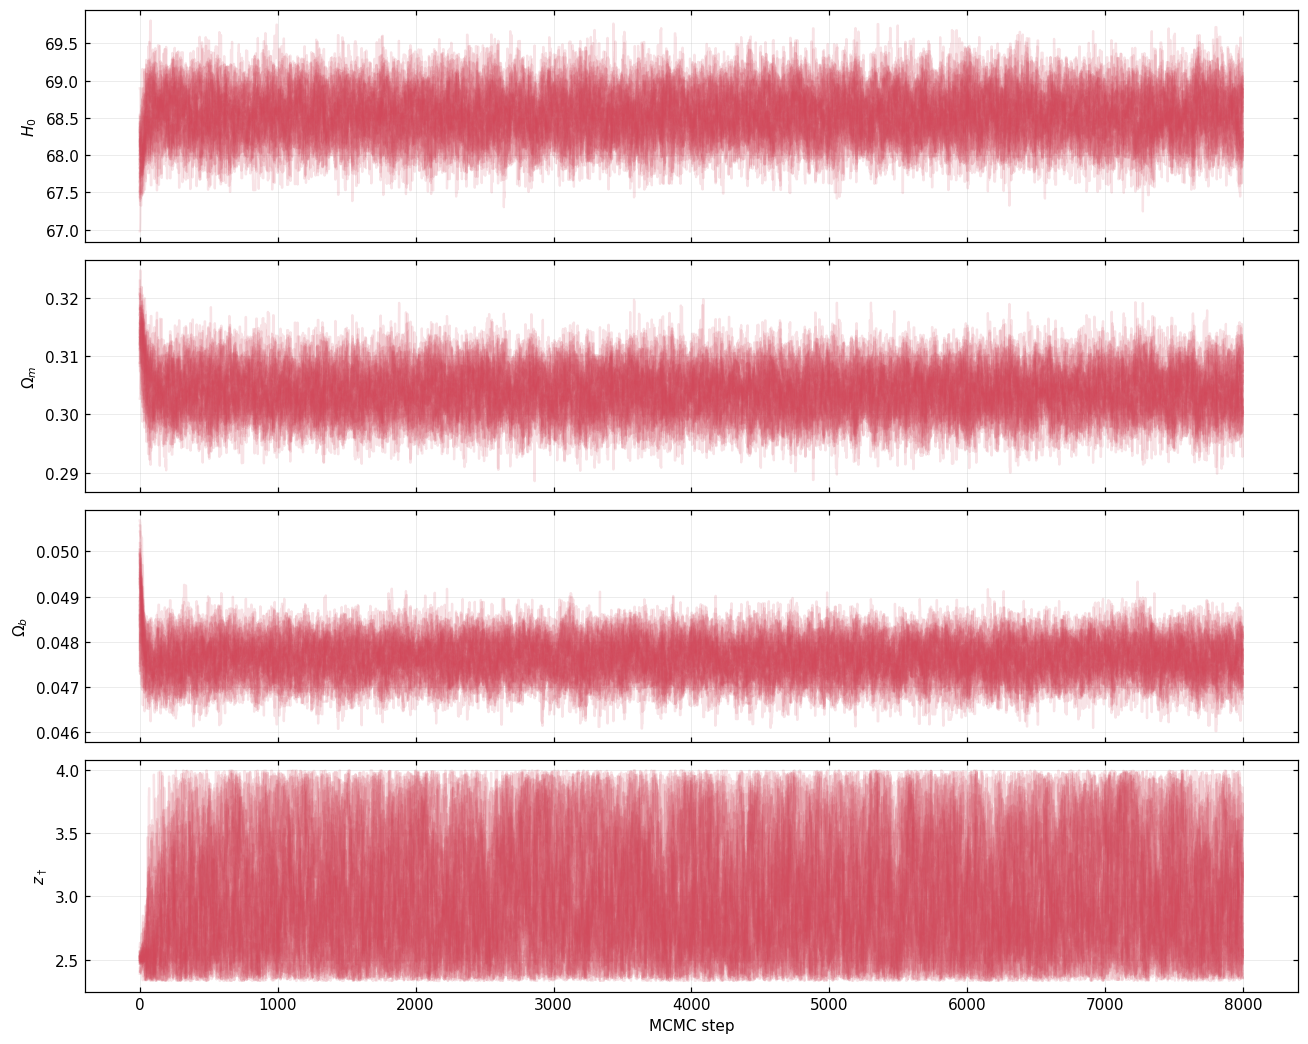

In [12]:
fig = fit.plots.chain()
savefig(fig, "chain");

saved corner.svg (0.90 MB)


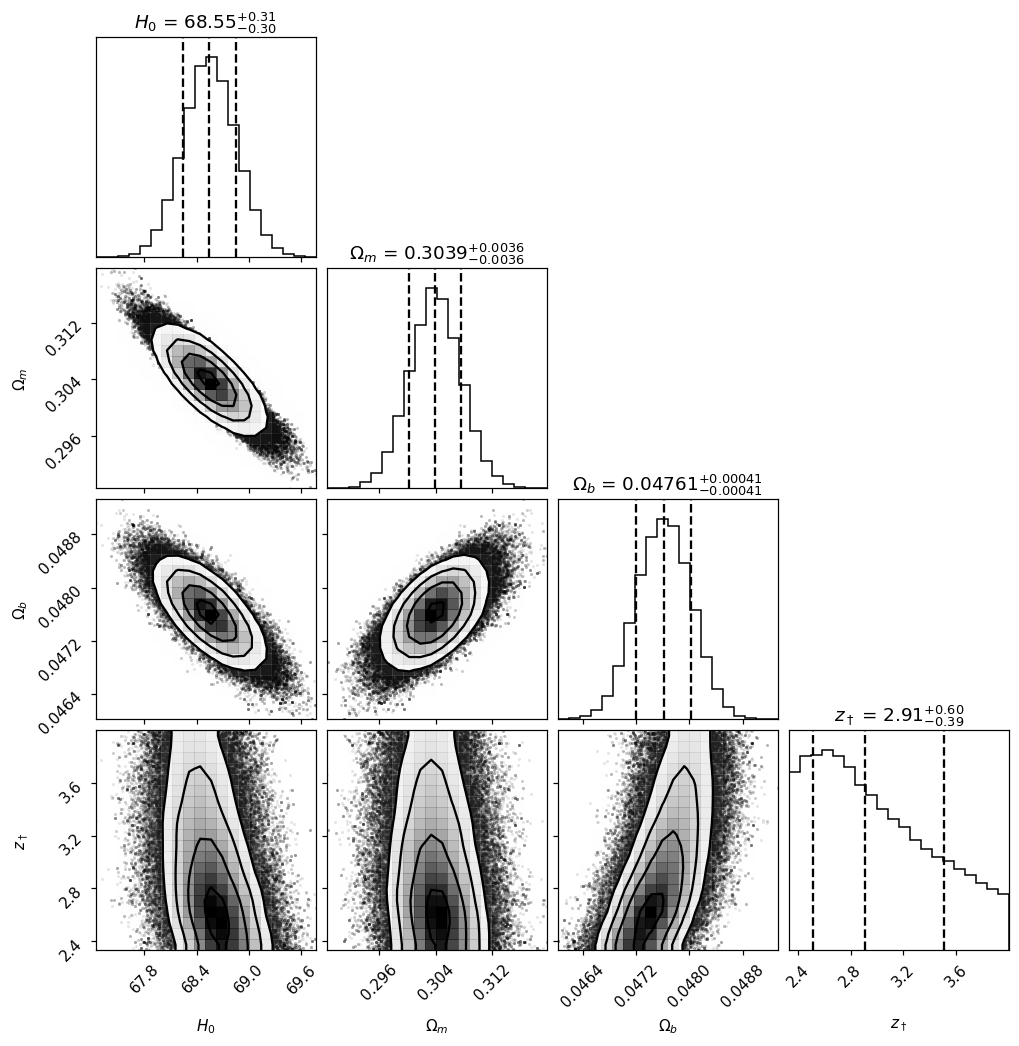

In [13]:
fig = fit.plots.corner()
savefig(fig, "corner");

## 8. Where the data puts $z_\dagger$ — the profile likelihood

The marginal posterior above is only half the story, because
$z_\dagger \to \infty$ *is* $\Lambda$CDM: push the switch beyond the
data and the model becomes indistinguishable from it. So the upper
tail of the posterior is a $\Lambda$CDM plateau, and its median moves
with the prior rather than with the data.

The profile likelihood does not have that problem. Fix $z_\dagger$,
re-optimize everything else, and plot $\chi^2$ against it. That is a
statement about the data alone.

In [14]:
def profile_chi2(z_dagger_values):
    """
    chi2 at each fixed z_dagger, with H0/Omega_m/Omega_b re-optimized.

    z_dagger is *fixed* rather than free here, which sidesteps the
    zero-gradient problem described above: the three remaining
    parameters are perfectly smooth and the optimizer handles them
    normally.
    """

    out = []

    for z_dagger in z_dagger_values:

        f = Fitter(
            model=LsCDM,
            datasets=DATASETS,
            dataset_kwargs=DATASET_KWARGS,
            free_params=["H0", "Omega_m", "Omega_b"],
            initial={**INITIAL, "z_dagger": float(z_dagger)},
            bounds={"z_dagger": (0.5, 100.0)},
            compute_rd=True,
        )

        f.best_fit()

        out.append((f.best_fit_chi2, f.best_fit_params["H0"]))

    return np.array(out)


Z_GRID = np.concatenate([
    np.arange(1.0, 4.01, 0.15),
    [4.5, 5.0, 6.0, 8.0, 12.0, 20.0, 50.0],
])

profile = profile_chi2(Z_GRID)

profile_chi2_values, profile_H0 = profile[:, 0], profile[:, 1]

The $\Lambda$CDM baseline it is measured against — the same data, the
same treatment of $r_d$, one fewer parameter:

In [15]:
fit_lcdm = Fitter(
    model=LCDM,
    datasets=DATASETS,
    dataset_kwargs=DATASET_KWARGS,
    free_params=["H0", "Omega_m", "Omega_b"],
    initial={k: v for k, v in INITIAL.items() if k != "z_dagger"},
    compute_rd=True,
)

fit_lcdm.run_mcmc(
    nwalkers=40, nsteps=6000, burnin=1000,
    seed=SEEDS["lcdm"], progress=True,
    save=CHAIN_DIR / "lcdm.h5",
)

fit_lcdm.best_fit()

print(f"\nLCDM converged: {fit_lcdm.convergence()['converged']}")
print(f"LCDM best-fit chi2 = {fit_lcdm.best_fit_chi2:.2f}\n")

for name, stats_ in fit_lcdm.summary().items():
    print(f"  {name:<10} = {stats_['median']:9.4f} "
          f"+{stats_['plus']:.4f} -{stats_['minus']:.4f}")

LCDM converged: True
LCDM best-fit chi2 = 1665.75
  H0         =   68.2527 +0.2849 -0.2779
  Omega_m    =    0.3028 +0.0036 -0.0037
  Omega_b    =    0.0483 +0.0003 -0.0003


saved zdagger_profile.svg (0.05 MB)


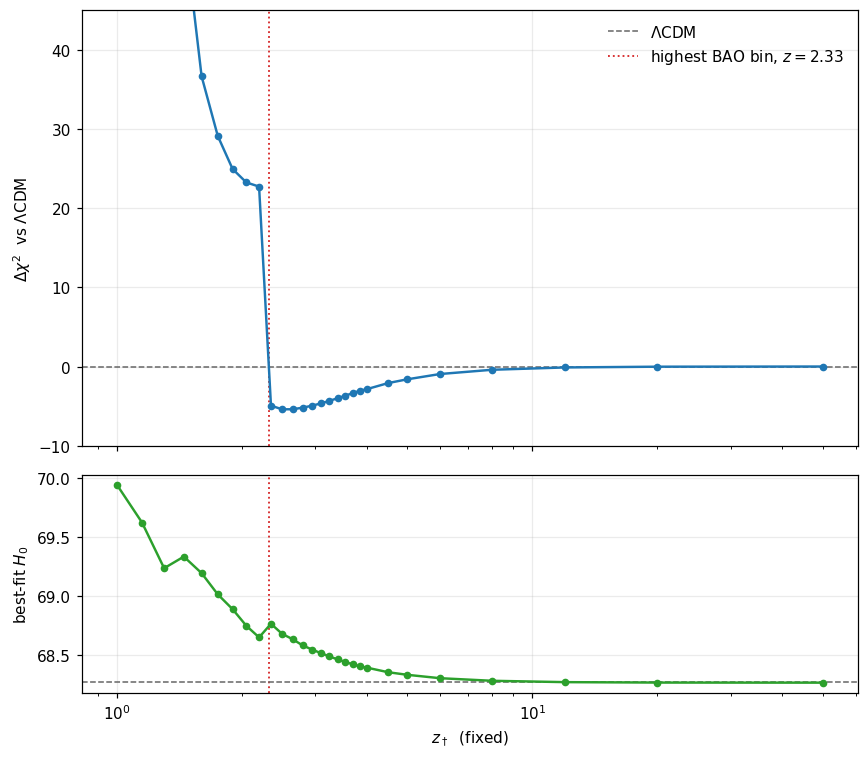

In [16]:
CHI2_LCDM = fit_lcdm.best_fit_chi2

delta_chi2 = profile_chi2_values - CHI2_LCDM

# The highest-redshift BAO measurement in the fit -- DESI DR2's
# Lyman-alpha forest bin. Read off the dataset rather than typed in,
# so it stays correct if the data version changes.
desi = next(lk for lk in fit.likelihoods if lk.name == "DESI")
Z_BAO_MAX = float(desi.data.z.max())

fig, (ax, ax_h0) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

ax.axhline(0.0, color="0.4", lw=1.0, ls="--",
           label=r"$\Lambda$CDM")
ax.axvline(Z_BAO_MAX, color="tab:red", lw=1.2, ls=":",
           label=rf"highest BAO bin, $z = {Z_BAO_MAX:.2f}$")
ax.plot(Z_GRID, delta_chi2, "o-", ms=4, lw=1.6, color="tab:blue")

ax.set_ylabel(r"$\Delta\chi^2$  vs $\Lambda$CDM")
ax.set_xscale("log")
ax.set_ylim(-10, 45)
ax.legend(frameon=False)
ax.grid(alpha=0.25)

ax_h0.axvline(Z_BAO_MAX, color="tab:red", lw=1.2, ls=":")
ax_h0.axhline(fit_lcdm.best_fit_params["H0"], color="0.4", lw=1.0, ls="--")
ax_h0.plot(Z_GRID, profile_H0, "o-", ms=4, lw=1.6, color="tab:green")
ax_h0.set_ylabel(r"best-fit $H_0$")
ax_h0.set_xlabel(r"$z_\dagger$  (fixed)")
ax_h0.grid(alpha=0.25)

fig.tight_layout()
savefig(fig, "zdagger_profile");

### Reading that figure

**A cliff at the highest BAO measurement.** Between $z_\dagger = 2.20$
and $z_\dagger = 2.35$ the fit improves by $\Delta\chi^2 \approx 28$.
That is not a coincidence of the grid: DESI DR2's Lyman-$\alpha$ bin
sits at $z = 2.33$, and the sign switch is only tolerated *above* it.
Put the transition inside the BAO range and $E(z)$ drops by a few
percent exactly where a $\sim$1%-precision distance has been measured;
by $z_\dagger = 1.0$ the penalty is $\Delta\chi^2 > 300$.

**A shallow minimum just above it,** $\Delta\chi^2 = -5.4$ at
$z_\dagger \approx 2.5$–$2.65$.

**A slow return to $\Lambda$CDM.** By $z_\dagger = 50$ the difference
is gone to two decimal places — the model has become $\Lambda$CDM, as
it must. That is also a check on the implementation: a model claiming
$\Lambda$CDM as a limit should reach it exactly, and this one does.

**And the bottom panel is the real result.** The $H_0$ that
$\Lambda_{\rm s}$CDM buys is largest where the switch is earliest —
$H_0 = 69.9$ at $z_\dagger = 1.0$ — and decays as $z_\dagger$ rises.
The data forces $z_\dagger$ up, into the region where the $H_0$ lift
has mostly gone.

## 9. Model comparison

$\Delta\chi^2 = -5.4$ for one extra parameter.

In [17]:
k_lscdm, k_lcdm = fit.ndim, fit_lcdm.ndim
chi2_lscdm = fit.best_fit_chi2

aic_lscdm = chi2_lscdm + 2 * k_lscdm
aic_lcdm = CHI2_LCDM + 2 * k_lcdm

bic_lscdm = chi2_lscdm + k_lscdm * np.log(fit.n_data)
bic_lcdm = CHI2_LCDM + k_lcdm * np.log(fit.n_data)

print(f"{'':<12}{'chi2':>10}{'k':>4}{'AIC':>11}{'BIC':>11}")
print(f"{'LCDM':<12}{CHI2_LCDM:>10.2f}{k_lcdm:>4}"
      f"{aic_lcdm:>11.2f}{bic_lcdm:>11.2f}")
print(f"{'LsCDM':<12}{chi2_lscdm:>10.2f}{k_lscdm:>4}"
      f"{aic_lscdm:>11.2f}{bic_lscdm:>11.2f}")
print(f"{'delta':<12}{chi2_lscdm - CHI2_LCDM:>+10.2f}{k_lscdm - k_lcdm:>+4}"
      f"{aic_lscdm - aic_lcdm:>+11.2f}{bic_lscdm - bic_lcdm:>+11.2f}")

                  chi2   k        AIC        BIC
LCDM           1665.75   3    1671.75    1688.35
LsCDM          1660.33   4    1668.33    1690.47
delta            -5.41  +1      -3.41      +2.12


$\Delta$AIC $\approx -3.4$ favours $\Lambda_{\rm s}$CDM; $\Delta$BIC
$\approx +2.1$ favours $\Lambda$CDM. The two disagree because BIC's
$k \ln n$ penalty is much harsher at $n = 1871$ — which is the usual
situation for a one-parameter extension with $\Delta\chi^2$ of a few,
and the honest summary is *neither model is preferred decisively*.

### No likelihood-ratio $p$-value

CosmoFit will compute one, and it should not be used here.

Wilks' theorem needs the null hypothesis to be an interior point of
the alternative's parameter space. $\Lambda$CDM is
$\Lambda_{\rm s}$CDM at $z_\dagger \to \infty$ — a limit, not a point,
and one that sits at the edge of any prior you could write down. The
profile above shows exactly this: $\Delta\chi^2$ approaches 0
asymptotically rather than reaching it at some finite $z_\dagger$. A
$\chi^2_1$ $p$-value computed from $\Delta\chi^2 = 5.4$ would be
`p = 0.020`, "2.3 sigma", and it would be meaningless. Quoting
$\Delta\chi^2$ and the information criteria is the defensible thing to
do.

## 10. Does it resolve the $H_0$ tension?

This is what the model is for. The comparison is against the local
distance ladder — **not** included in the fit, so that it can be used
as an independent check rather than as data the fit was already told
about.

In [18]:
from CosmoFit.data.loader import load_gaussian_prior

sh0es = load_gaussian_prior("h0", "sh0es2022")

print(f"SH0ES: H0 = {sh0es.value:.2f} +- {sh0es.sigma:.2f}  "
      f"({sh0es.reference})\n")


def tension_sigma(summary):
    """
    Gaussian tension in sigma between a fitted H0 and SH0ES,
    combining the two uncertainties in quadrature.
    """

    median = summary["H0"]["median"]
    sigma = 0.5 * (summary["H0"]["plus"] + summary["H0"]["minus"])

    return (
        (sh0es.value - median)
        / np.sqrt(sigma ** 2 + sh0es.sigma ** 2)
    )


rows = []
for label, f in (("LCDM", fit_lcdm), ("LsCDM", fit)):
    s = f.summary()
    sigma = 0.5 * (s["H0"]["plus"] + s["H0"]["minus"])
    rows.append((label, s["H0"]["median"], sigma, tension_sigma(s)))
    print(f"{label:<7} H0 = {s['H0']['median']:.2f} +- {sigma:.2f}   "
          f"tension with SH0ES: {tension_sigma(s):.1f} sigma")

SH0ES: H0 = 73.04 +- 1.04  (Riess et al. (2022), ApJ 934, L7, arXiv:2112.04510)
LCDM    H0 = 68.25 +- 0.28   tension with SH0ES: 4.4 sigma
LsCDM   H0 = 68.55 +- 0.30   tension with SH0ES: 4.1 sigma


saved h0_tension.svg (0.04 MB)


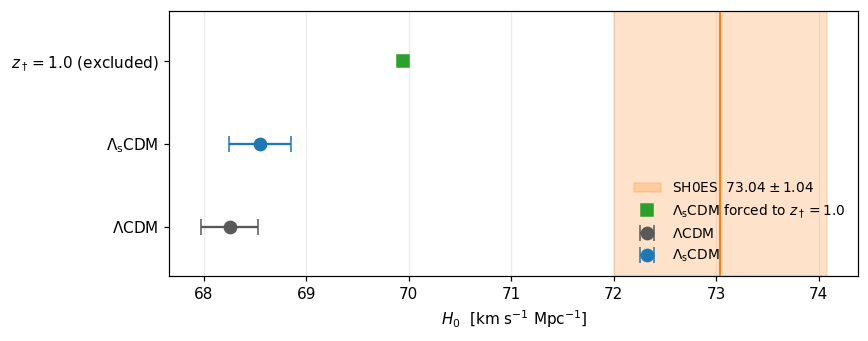

In [19]:
fig, ax = plt.subplots(figsize=(8, 3.2))

ax.axvspan(
    sh0es.value - sh0es.sigma, sh0es.value + sh0es.sigma,
    color="tab:orange", alpha=0.22,
    label=rf"SH0ES  ${sh0es.value:.2f} \pm {sh0es.sigma:.2f}$",
)
ax.axvline(sh0es.value, color="tab:orange", lw=1.4)

colors = {"LCDM": "0.35", "LsCDM": "tab:blue"}
labels = {"LCDM": r"$\Lambda$CDM", "LsCDM": r"$\Lambda_{\rm s}$CDM"}

for i, (label, median, sigma, _) in enumerate(rows):
    ax.errorbar(
        median, i, xerr=sigma, fmt="o", ms=8, capsize=5,
        color=colors[label], label=labels[label],
    )

# What the model would have delivered had the data allowed an early
# switch -- the profile's own H0 at its lowest z_dagger.
ax.plot(
    profile_H0[0], len(rows), "s", ms=8, color="tab:green",
    label=rf"$\Lambda_{{\rm s}}$CDM forced to $z_\dagger = {Z_GRID[0]:.1f}$",
)

ax.set_yticks(range(len(rows) + 1))
ax.set_yticklabels(
    [labels[r[0]] for r in rows]
    + [rf"$z_\dagger = {Z_GRID[0]:.1f}$ (excluded)"]
)
ax.set_ylim(-0.6, len(rows) + 0.6)
ax.set_xlabel(r"$H_0$  [km s$^{-1}$ Mpc$^{-1}$]")
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.25)

fig.tight_layout()
savefig(fig, "h0_tension");

### The answer is no — and the reason is specific

$\Lambda_{\rm s}$CDM moves $H_0$ from $68.25 \pm 0.28$ to
$68.55 \pm 0.30$ — up by $0.3$ km s$^{-1}$ Mpc$^{-1}$, against the
$4.5$ that would be needed to reach SH0ES. The tension goes from
$4.4\sigma$ to $4.1\sigma$: a real but marginal improvement, and
nothing like a resolution.

That is a different answer from the model's original papers, which
report $H_0 \approx 70$ and a substantially relieved tension — and the
profile likelihood says why. Those analyses find $z_\dagger \approx
1.7$–$2.3$, and it is precisely there that the $H_0$ lift lives: the
bottom panel of the profile figure gives $H_0 = 69.2$ at $z_\dagger =
1.6$ and $68.6$ at $z_\dagger = 2.5$.

**DESI DR2 excludes that range.** Its Lyman-$\alpha$ BAO measurement at
$z = 2.33$ sits inside it, and a sign switch below that redshift costs
$\Delta\chi^2 \gtrsim 23$. The transition is pushed above the data, and
the mechanism goes with it.

The residual $\Delta\chi^2 = -5.4$ at $z_\dagger \approx 2.5$ is a mild
preference for *something* just above the BAO range — but it is not the
$H_0$-resolving something the model was proposed for.

> Worth stating plainly: this is one data combination with a
> compressed CMB likelihood, not a replacement for the full analyses
> those papers run. The point is not that the published results are
> wrong — it is that this particular combination, with the 2025 BAO
> data, does not reproduce them, and the profile shows exactly which
> measurement is responsible.

## 11. Data against model

The standard cosmology figures, with $\Lambda$CDM overlaid on the same
axes. Two of them are worth looking at closely: the BAO panel, because
that is where the constraint on $z_\dagger$ comes from, and the Planck
pull plot, because that is where the $\chi^2$ improvement comes from.

saved compare_bao_distances.svg (0.17 MB)


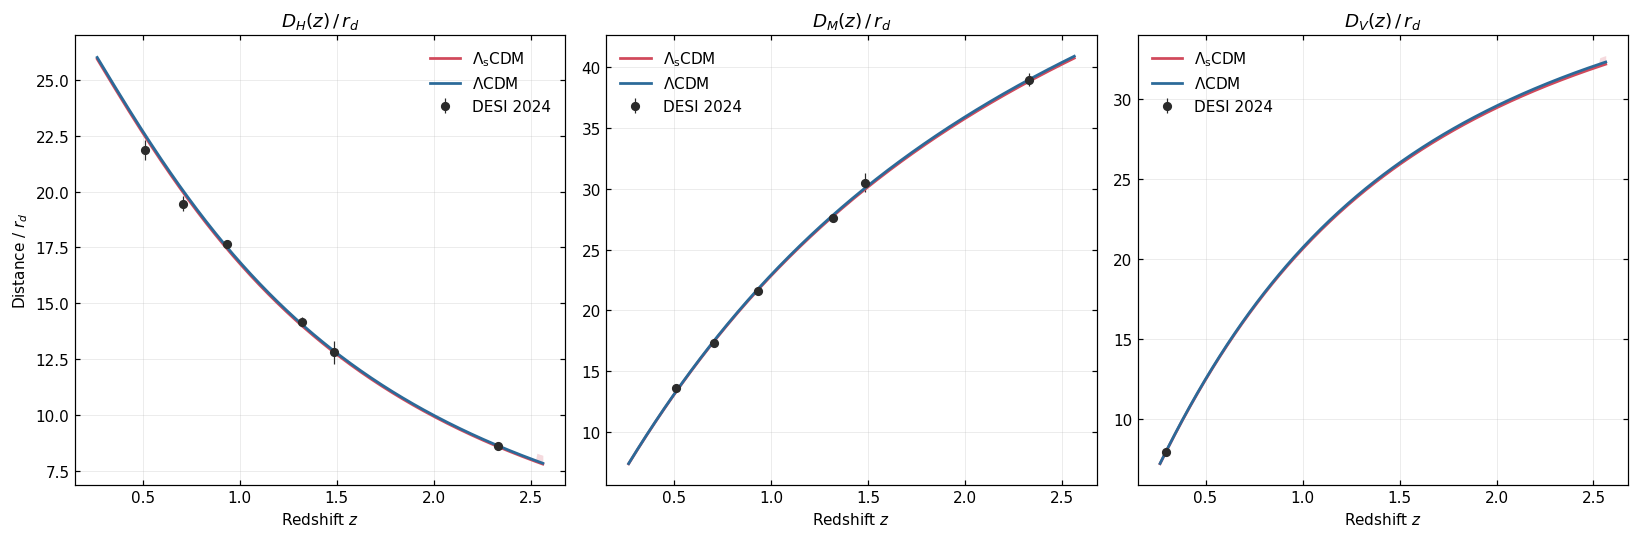

In [20]:
fig = fit.plots.compare_bao_distances(other_fits=fit_lcdm)
savefig(fig, "compare_bao_distances");

saved compare_hz.svg (0.08 MB)


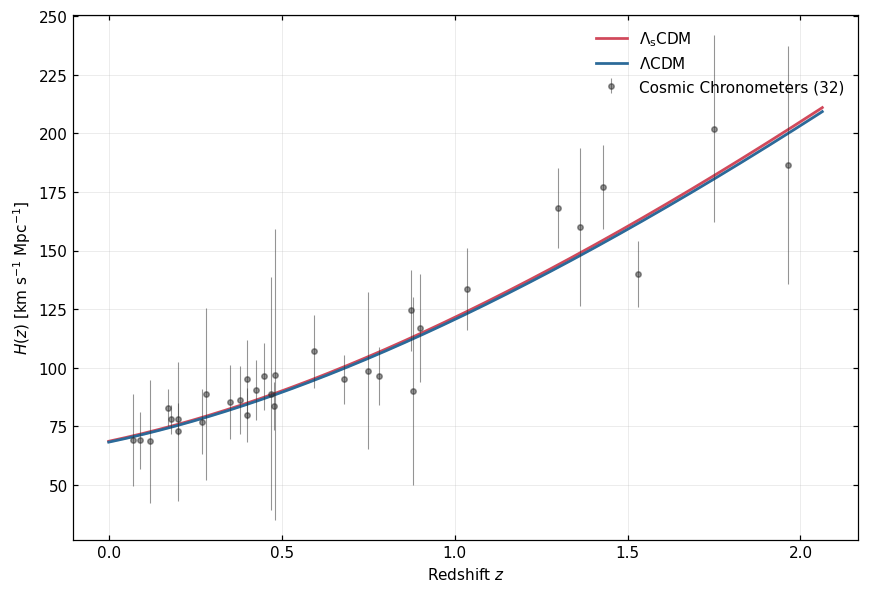

In [21]:
fig = fit.plots.compare_hz(other_fits=fit_lcdm)
savefig(fig, "compare_hz");

saved compare_des_hubble_diagram.svg (0.64 MB)


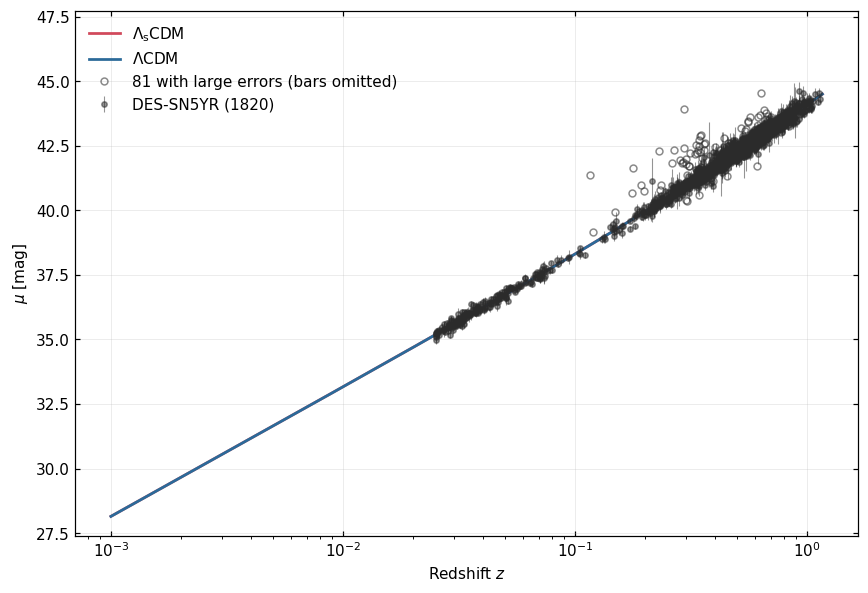

In [22]:
fig = fit.plots.compare_des_hubble_diagram(other_fits=fit_lcdm)
savefig(fig, "compare_des_hubble_diagram");

### Where the improvement actually is

$\Delta\chi^2 = -5.4$ split by dataset. This is the check that
distinguishes "the model fits better" from "the model fits three
compressed numbers better".

In [23]:
import pandas as pd

rows = []
for lscdm_lk, lcdm_lk in zip(fit.likelihoods, fit_lcdm.likelihoods):
    rows.append({
        "dataset": lscdm_lk.name,
        "N": lscdm_lk.n_data,
        "LCDM": lcdm_lk.chi2(),
        "LsCDM": lscdm_lk.chi2(),
        "delta": lscdm_lk.chi2() - lcdm_lk.chi2(),
    })

breakdown = pd.DataFrame(rows)
breakdown.loc[len(breakdown)] = {
    "dataset": "TOTAL", "N": fit.n_data,
    "LCDM": breakdown["LCDM"].sum(),
    "LsCDM": breakdown["LsCDM"].sum(),
    "delta": breakdown["delta"].sum(),
}

breakdown.round(2)

,dataset,N,LCDM,LsCDM,delta
0,CC,32,13.14,13.07,-0.07
1,DESI,13,13.00,11.00,-2.01
2,BAO low-z,2,1.56,1.72,0.16
3,DES-SN5YR,1820,1634.86,1634.40,-0.46
4,Planck,3,2.85,0.08,-2.77
5,BBN,1,0.34,0.07,-0.27
6,TOTAL,1871,1665.75,1660.33,-5.41


Read the `delta` column. The improvement is carried almost entirely by
**Planck** and **DESI** — the two datasets that constrain distances at
and above $z_\dagger$. The supernovae, which live entirely below the
transition, barely move: they cannot see it.

That is internally consistent with the mechanism, and it is also the
weak point of the result. Planck contributes through three compressed
numbers, and a $\Delta\chi^2$ of a few on three numbers is exactly the
regime where the compression's conventions matter. The full spectra
would settle it — and, as established above, cannot be computed for
this model.

saved planck_residuals.svg (0.03 MB)


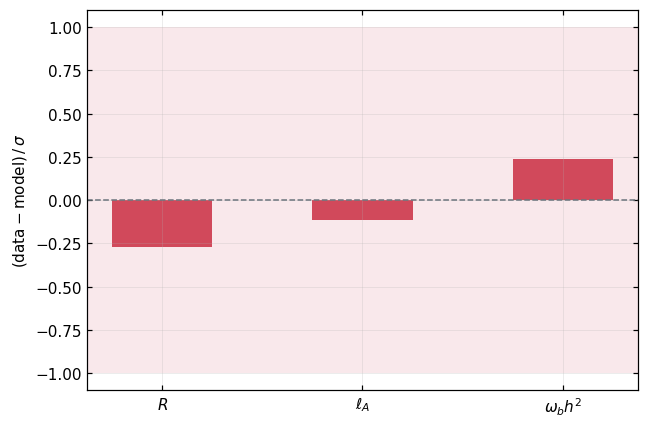

In [24]:
fig = fit.plots.planck_residuals()
savefig(fig, "planck_residuals");

### The expansion history itself

$q(z)$ makes the discontinuity visible. The deceleration parameter
jumps at $z_\dagger$ — it is genuinely undefined *at* the transition,
and the curve either side of it is what the model says.

saved compare_deceleration.svg (0.06 MB)


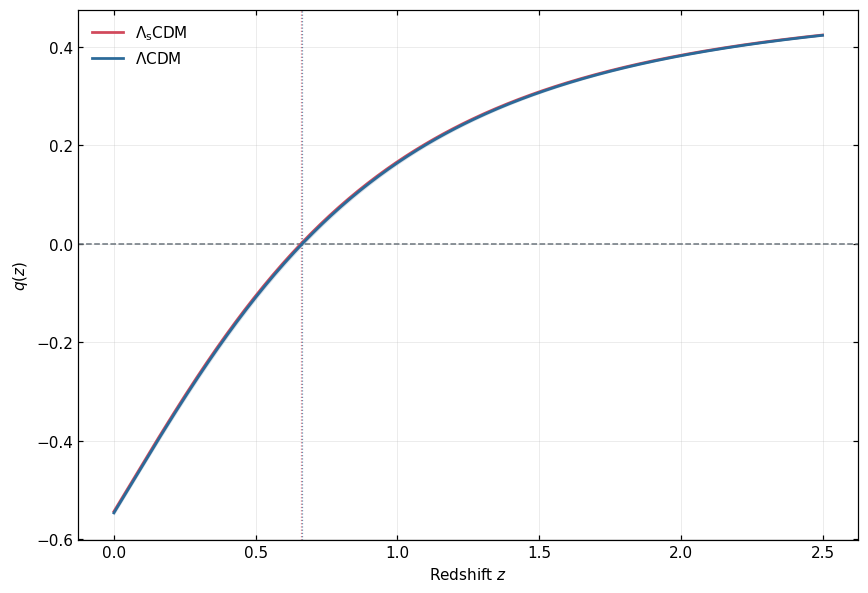

In [25]:
fig = fit.plots.compare_deceleration(other_fits=fit_lcdm)
savefig(fig, "compare_deceleration");

saved expansion_history.svg (0.05 MB)


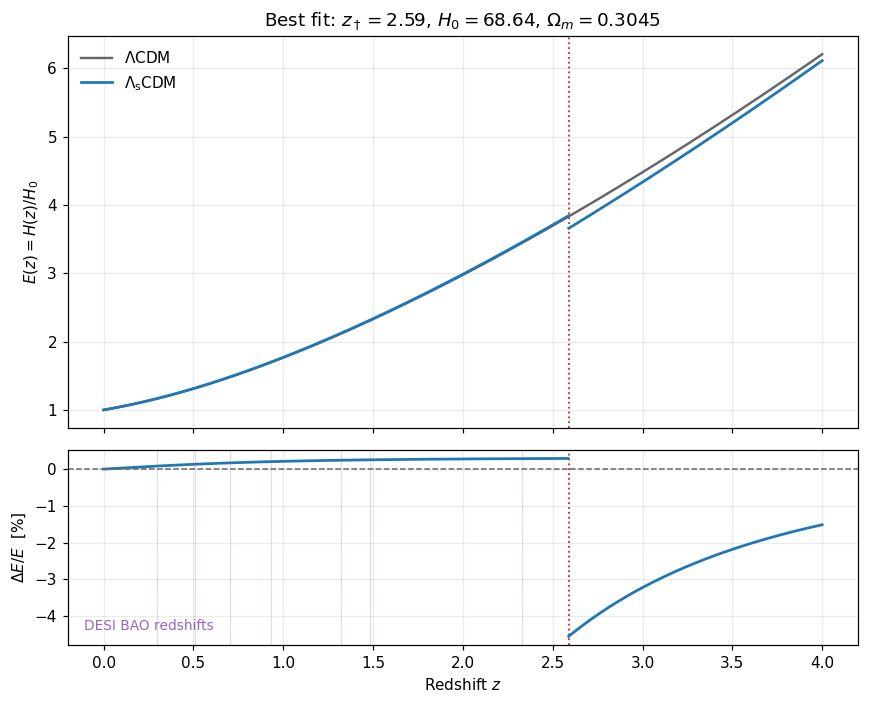

In [26]:
z = np.linspace(0.0, 4.0, 1200)

best = fit.best_fit_params
z_dagger = best["z_dagger"]

cosmo_lscdm = fit.cosmology
cosmo_lcdm = fit_lcdm.cosmology

fig, (ax_e, ax_ratio) = plt.subplots(
    2, 1, figsize=(8, 6.5), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

E_lscdm = np.asarray(cosmo_lscdm.E(z))
E_lcdm = np.asarray(cosmo_lcdm.E(z))

below = z <= z_dagger

for ax in (ax_e, ax_ratio):
    ax.axvline(z_dagger, color="tab:red", lw=1.2, ls=":")

ax_e.plot(z, E_lcdm, color="0.4", lw=1.6, label=r"$\Lambda$CDM")
ax_e.plot(z[below], E_lscdm[below], color="tab:blue", lw=1.8,
          label=r"$\Lambda_{\rm s}$CDM")
ax_e.plot(z[~below], E_lscdm[~below], color="tab:blue", lw=1.8)
ax_e.set_ylabel(r"$E(z) = H(z)/H_0$")
ax_e.legend(frameon=False)
ax_e.grid(alpha=0.25)
ax_e.set_title(
    rf"Best fit: $z_\dagger = {z_dagger:.2f}$, "
    rf"$H_0 = {best['H0']:.2f}$, $\Omega_m = {best['Omega_m']:.4f}$"
)

ratio = E_lscdm / E_lcdm - 1.0
ax_ratio.plot(z[below], 100 * ratio[below], color="tab:blue", lw=1.8)
ax_ratio.plot(z[~below], 100 * ratio[~below], color="tab:blue", lw=1.8)
ax_ratio.axhline(0.0, color="0.4", lw=1.0, ls="--")

# Where the BAO measurements actually are, since the size of the jump
# only matters relative to data that could see it.
for z_bao in np.unique(desi.data.z):
    ax_ratio.axvline(z_bao, color="tab:purple", alpha=0.25, lw=0.8)

ax_ratio.set_ylabel(r"$\Delta E / E$  [%]")
ax_ratio.set_xlabel(r"Redshift $z$")
ax_ratio.grid(alpha=0.25)
ax_ratio.annotate(
    "DESI BAO redshifts", xy=(0.02, 0.08),
    xycoords="axes fraction", color="tab:purple", fontsize=9,
)

fig.tight_layout()
savefig(fig, "expansion_history");

The jump in $E(z)$ at the best fit is about 1.5%, and it happens just
past the last purple line — the highest BAO redshift. The bottom panel
is the constraint in one picture: the transition has been pushed to
the first place where nothing is measuring it.

## 12. How much of this is the prior?

$z_\dagger \to \infty$ is $\Lambda$CDM, so the posterior has an
unbounded plateau and its *marginal* summary must depend on where the
prior is cut. Worth measuring rather than asserting.

In [27]:
def zdagger_posterior(upper):
    """Refit with the z_dagger prior cut at `upper`."""

    f = Fitter(
        model=LsCDM,
        datasets=DATASETS,
        dataset_kwargs=DATASET_KWARGS,
        free_params=FREE_LSCDM,
        initial=INITIAL,
        bounds={"z_dagger": (0.5, upper)},
        compute_rd=True,
    )

    f.run_mcmc(
        nwalkers=24, nsteps=2500, burnin=500,
        seed=SEEDS["lscdm"], progress=False,
        save=CHAIN_DIR / f"lscdm_prior_{upper:g}.h5",
    )

    samples = f.samples_dict()["z_dagger"]

    return np.percentile(samples, [2.5, 50, 97.5]), f.summary()["H0"]


print(f"{'prior upper':>12}{'z_dagger (95% CI)':>28}{'H0':>18}")

for upper in (4.0, 6.0, 15.0):
    (lo, mid, hi), h0 = zdagger_posterior(upper)
    print(f"{upper:>12.1f}   {mid:>6.2f}  [{lo:.2f}, {hi:5.2f}]"
          f"       {h0['median']:.3f} +- "
          f"{0.5 * (h0['plus'] + h0['minus']):.3f}")

 prior upper           z_dagger (95% CI)                H0


         4.0     2.94  [2.36,  3.92]       68.558 +- 0.308


         6.0     3.11  [2.38,  5.60]       68.510 +- 0.322


        15.0     3.93  [2.39, 14.40]       68.429 +- 0.326


The **upper** end tracks the prior, exactly as the plateau implies —
so a quoted "$z_\dagger = 2.9 \pm 0.5$" would be a statement about the
prior, not the data.

The **lower** end does not move: the 95% limit sits at $2.36$,
$2.38$, $2.39$ as the prior is widened from 4 to 15 — the same number
three times. That is the real measurement, it is what the profile's
cliff corresponds to, and it is what should be quoted.

$H_0$ barely moves either — which is the point. Wherever the plateau
is cut, the model has already stopped raising $H_0$.

## 13. Derived quantities

Every posterior sample pushed back through the model's own $E(z)$, so
these carry real uncertainties rather than being evaluated once at the
best fit.

In [28]:
rows = []

for label, f in (("LCDM", fit_lcdm), ("LsCDM", fit)):
    q0 = derived.summarize(derived.deceleration_today(f))
    z_t = derived.summarize(derived.transition_redshift(f))
    r_d = derived.summarize(derived.sound_horizon(f))

    rows.append({
        "model": label,
        "q0": f"{q0['median']:.3f} +{q0['plus']:.3f} -{q0['minus']:.3f}",
        "z_t (acceleration)": f"{z_t['median']:.3f} "
                              f"+{z_t['plus']:.3f} -{z_t['minus']:.3f}",
        "r_d [Mpc]": f"{r_d['median']:.2f} "
                     f"+{r_d['plus']:.2f} -{r_d['minus']:.2f}",
    })

pd.DataFrame(rows)

,model,q0,z_t (acceleration),r_d [Mpc]
0,LCDM,-0.546 +0.005 -0.006,0.664 +0.010 -0.009,147.52 +0.19 -0.20
1,LsCDM,-0.544 +0.006 -0.005,0.661 +0.009 -0.010,147.16 +0.22 -0.23


$r_d$ comes out at $147.52$ Mpc for $\Lambda$CDM and $147.16$ Mpc
for $\Lambda_{\rm s}$CDM. The 0.24% difference is **not** the sign
switch: the sound-horizon integral runs from the drag epoch upward,
where the $\Lambda$ term of either sign is $\sim 10^{-8}$ of the
matter density and cannot matter. It is the slightly different
$\omega_b$ and $\omega_{cb}$ the two fits prefer.

That is worth being clear about, because "$\Lambda_{\rm s}$CDM
shrinks the standard ruler" would be a natural guess and is wrong.
The model does not touch $r_d$; it changes the distance the ruler is
compared against.

Note also that $z_t$, the *acceleration* transition, is a different
quantity from $z_\dagger$, the *sign-switch* transition. The universe
starts accelerating at $z_t \approx 0.6$; $\Lambda$ flips sign at
$z_\dagger \approx 2.5$. Nothing requires them to coincide, and they
do not.

## 14. The other half of the claim: $S_8$

$\Lambda_{\rm s}$CDM is proposed as a *joint* fix — $H_0$ **and**
$S_8$. The $H_0$ half is settled above. This section tests the other.

$S_8 \equiv \sigma_8 \sqrt{\Omega_m / 0.3}$ measures how clumpy the
late universe is. Weak-lensing surveys measure it and find values a
few percent below what Planck's $\Lambda$CDM predicts — the $S_8$
tension. A model that suppresses structure growth relative to
$\Lambda$CDM would relieve it.

$\Lambda_{\rm s}$CDM is **not** modified gravity: it is GR with an
unusual $\Lambda$, so it inherits the standard growth equation
($\mu = 1$) and its only handle on structure is its own $E(z)$. The
prediction is therefore fixed — there is nothing to tune.

### Why this is a separate fit

**Practical:** growth data costs a linear-growth ODE solve per
likelihood evaluation, taking this fit from 1.5 ms per step to 30 ms
— twenty times slower.

**Scientific:** the $H_0$ result above should stay comparable to the
published $\Lambda_{\rm s}$CDM analyses, which are built on background
probes. Keeping growth in its own fit isolates what adding it does
rather than entangling two effects in one number.

### A caveat about overlapping surveys

The Gold-2018 compilation contains RSD measurements from surveys whose
BAO is already in this fit. Most directly, **SDSS DR7 MGS appears
twice**: as a BAO point at $z = 0.15$ in `bao_lowz`, and as an
$f\sigma_8$ point at the same $z = 0.15$ from the same galaxies. The
three $z = 0.02$ points are 6dFGS peculiar velocities, and 6dFGS's BAO
is in `bao_lowz` too.

BAO and RSD extract different information from the same galaxies, so
this is not the flat double-counting that combining two supernova
compilations would be — but they are correlated, and no joint
covariance is published. Treating them as independent is standard
practice and is what is done here. It means the error bars below are,
if anything, slightly optimistic.

In [29]:
DATASETS_GROWTH = DATASETS + ["fsigma8", "s8"]

# sigma8 joins the free parameters: nothing in the background-only fit
# constrained it, and now two datasets do.
#
# Written out in full rather than as `FREE_LSCDM + ["sigma8"]`. A
# saved chain stores its columns in free-parameter order, so the
# *order* is part of what identifies it -- and `ChainFile` refuses to
# resume a chain whose order differs, which is the right call even
# though the posterior is the same set of parameters either way.
FREE_LSCDM_GROWTH = ["H0", "Omega_m", "Omega_b", "sigma8", "z_dagger"]
FREE_LCDM_GROWTH = ["H0", "Omega_m", "Omega_b", "sigma8"]

INITIAL_GROWTH = {**INITIAL, "sigma8": 0.811}

fit_growth = Fitter(
    model=LsCDM,
    datasets=DATASETS_GROWTH,
    dataset_kwargs=DATASET_KWARGS,
    free_params=FREE_LSCDM_GROWTH,
    initial=INITIAL_GROWTH,
    compute_rd=True,
)

print(f"data points: {fit_growth.n_data} "
      f"(+{fit_growth.n_data - fit.n_data} from growth)")

fit_growth.run_mcmc(
    nwalkers=32, nsteps=6500, burnin=1000,
    seed=SEEDS["lscdm_growth"], progress=True,
    save=CHAIN_DIR / "lscdm_growth.h5",
)

fit_growth.best_fit()

print(f"\nconverged: {fit_growth.convergence()['converged']}")
for name, stats_ in fit_growth.summary().items():
    print(f"  {name:<10} = {stats_['median']:9.4f} "
          f"+{stats_['plus']:.4f} -{stats_['minus']:.4f}")

data points: 1894 (+23 from growth)


converged: True
  H0         =   68.5953 +0.2994 -0.3042
  Omega_m    =    0.3033 +0.0037 -0.0035
  Omega_b    =    0.0476 +0.0004 -0.0004
  sigma8     =    0.7579 +0.0175 -0.0180
  z_dagger   =    2.8869 +0.5999 -0.3800


In [30]:
fit_lcdm_growth = Fitter(
    model=LCDM,
    datasets=DATASETS_GROWTH,
    dataset_kwargs=DATASET_KWARGS,
    free_params=FREE_LCDM_GROWTH,
    initial=INITIAL_GROWTH,
    compute_rd=True,
)

fit_lcdm_growth.run_mcmc(
    nwalkers=32, nsteps=6500, burnin=1000,
    seed=SEEDS["lcdm_growth"], progress=True,
    save=CHAIN_DIR / "lcdm_growth.h5",
)

fit_lcdm_growth.best_fit()

print(f"\nconverged: {fit_lcdm_growth.convergence()['converged']}")
for name, stats_ in fit_lcdm_growth.summary().items():
    print(f"  {name:<10} = {stats_['median']:9.4f} "
          f"+{stats_['plus']:.4f} -{stats_['minus']:.4f}")

converged: True
  H0         =   68.2881 +0.2806 -0.2824
  Omega_m    =    0.3023 +0.0037 -0.0035
  Omega_b    =    0.0483 +0.0003 -0.0003
  sigma8     =    0.7592 +0.0181 -0.0180


### Before reading the $S_8$ numbers: what this fit can and cannot say

The canonical $S_8$ tension is between what the **CMB predicts** and
what **lensing measures**. Posing it needs the CMB's amplitude — $A_s$,
which lives in the height of the acoustic peaks.

The CMB enters this notebook as $(R, \ell_A, \omega_b h^2)$: three
*distance* numbers. **None of them carries any amplitude
information.** So $\sigma_8$ here is constrained by the growth data and
nothing else, and it simply floats to whatever $f\sigma_8$ and $S_8$
want — for both models equally. The $S_8$ dataset's $\chi^2$ below is
$\approx 0.01$, which is not a success; it is a free parameter
absorbing a single data point.

**Reporting "the fit agrees with KiDS-1000" would therefore be
circular**, and this notebook does not.

What survives that objection is the *relative* comparison. Both models
were given the same freedom and the same data; if
$\Lambda_{\rm s}$CDM's growth physics shifted $S_8$, the two would
land in different places. That comparison is unaffected by the
circularity, because it affects both identically.

In [31]:
def s8_samples(f):
    """S8 = sigma8 sqrt(Omega_m / 0.3), one value per posterior sample."""

    s = f.samples_dict()

    return s["sigma8"] * np.sqrt(s["Omega_m"] / 0.3)


from CosmoFit.data.loader import load_s8

# kids1000 is the version in the fit; des_y3 is a different survey and
# is *not* in it, so it is at least an out-of-sample check -- a weak
# one, since the two lensing results agree with each other.
lensing = {
    version: load_s8(version) for version in ("kids1000", "des_y3")
}

for version, data in lensing.items():
    in_fit = "in the fit" if version == "kids1000" else "NOT in the fit"
    print(f"{version:>10}: S8 = {data.value:.3f} +- {data.sigma:.3f}   ({in_fit})")

print()

s8_rows = []
for label, f in (("LCDM", fit_lcdm_growth), ("LsCDM", fit_growth)):

    values = s8_samples(f)
    lo, mid, hi = np.percentile(values, [16, 50, 84])
    sigma = 0.5 * (hi - lo)

    s8_rows.append((label, mid, sigma))

    des = lensing["des_y3"]
    pull = (mid - des.value) / np.sqrt(sigma ** 2 + des.sigma ** 2)

    print(f"{label:<7} S8 = {mid:.4f} +- {sigma:.4f}"
          f"    vs DES Y3 (out of sample): {pull:+.1f} sigma")

print(f"\ndifference between the two models: "
      f"{abs(s8_rows[1][1] - s8_rows[0][1]):.5f}  "
      f"({100 * abs(s8_rows[1][1] - s8_rows[0][1]) / s8_rows[0][1]:.2f}%)")

  kids1000: S8 = 0.759 +- 0.022   (in the fit)
    des_y3: S8 = 0.776 +- 0.017   (NOT in the fit)
LCDM    S8 = 0.7621 +- 0.0179    vs DES Y3 (out of sample): -0.6 sigma
LsCDM   S8 = 0.7623 +- 0.0174    vs DES Y3 (out of sample): -0.6 sigma
difference between the two models: 0.00023  (0.03%)


saved s8_comparison.svg (0.05 MB)


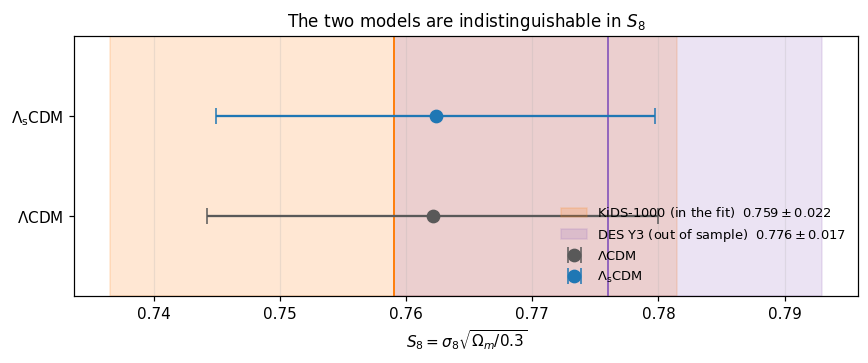

In [32]:
fig, ax = plt.subplots(figsize=(8, 3.4))

palette = {"kids1000": "tab:orange", "des_y3": "tab:purple"}
names = {"kids1000": "KiDS-1000 (in the fit)",
         "des_y3": "DES Y3 (out of sample)"}

for version, data in lensing.items():
    ax.axvspan(
        data.value - data.sigma, data.value + data.sigma,
        color=palette[version], alpha=0.18,
        label=rf"{names[version]}  ${data.value:.3f} \pm {data.sigma:.3f}$",
    )
    ax.axvline(data.value, color=palette[version], lw=1.3)

colors = {"LCDM": "0.35", "LsCDM": "tab:blue"}
labels = {"LCDM": r"$\Lambda$CDM", "LsCDM": r"$\Lambda_{\rm s}$CDM"}

for i, (label, mid, sigma) in enumerate(s8_rows):
    ax.errorbar(
        mid, i, xerr=sigma, fmt="o", ms=8, capsize=5,
        color=colors[label], label=labels[label],
    )

ax.set_yticks(range(len(s8_rows)))
ax.set_yticklabels([labels[r[0]] for r in s8_rows])
ax.set_ylim(-0.8, len(s8_rows) - 0.2)
ax.set_xlabel(r"$S_8 = \sigma_8\sqrt{\Omega_m/0.3}$")
ax.set_title(
    r"The two models are indistinguishable in $S_8$",
    fontsize=11,
)
ax.legend(frameon=False, loc="lower right", fontsize=8.5)
ax.grid(axis="x", alpha=0.25)

fig.tight_layout()
savefig(fig, "s8_comparison");

### The prediction, isolated from the fit

The cleanest statement avoids the fitting entirely: hold every
parameter fixed and ask what the two models predict for $f\sigma_8$.
Any difference is the sign switch and nothing else.

In [33]:
shared = {
    "H0": 68.6, "Omega_m": 0.304, "Omega_b": 0.0474, "sigma8": 0.80,
}

z_growth = np.array([0.0, 0.3, 0.6, 1.0, 1.5])

lcdm_at_shared = LCDM(LCDM.PARAMS_CLASS(**shared))

print(f"{'z':>6}{'LCDM':>12}{'LsCDM':>12}{'ratio':>10}")

for z_value, a, b in zip(
    z_growth,
    lcdm_at_shared.growth.fsigma8(z_growth),
    LsCDM(
        LsCDM.PARAMS_CLASS(**shared, z_dagger=2.6),
    ).growth.fsigma8(z_growth),
):
    print(f"{z_value:>6.1f}{a:>12.5f}{b:>12.5f}{b / a:>10.5f}")

# The LCDM limit, as a check that the difference above is real and not
# numerical noise in the ODE solve.
far = LsCDM(LsCDM.PARAMS_CLASS(**shared, z_dagger=50.0))

print(f"\nz_dagger = 50 reproduces LCDM: "
      f"{np.allclose(far.growth.fsigma8(z_growth), lcdm_at_shared.growth.fsigma8(z_growth))}")

     z        LCDM       LsCDM     ratio


   0.0     0.41331     0.41487   1.00376
   0.3     0.46166     0.46395   1.00497
   0.6     0.46065     0.46371   1.00665
   1.0     0.42550     0.42965   1.00974
   1.5     0.37057     0.37618   1.01516
z_dagger = 50 reproduces LCDM: True


At identical parameters $\Lambda_{\rm s}$CDM predicts **more**
clustering than $\Lambda$CDM, not less. The negative $\Lambda$ above
$z_\dagger$ lowers $E(z)$ there, which raises
$\Omega_m(a) = \Omega_m (1+z)^3 / E^2$ — the source term of the growth
equation. More source, more growth.

The effect grows with redshift (1.5% by $z = 1.5$) but shrinks toward
the present, and $\sigma_8$ is a $z = 0$ quantity: **0.4% at $z = 0$**
is the number that bears on $S_8$.

That is the wrong direction for the tension, and the size settles it.
Planck's $\Lambda$CDM predicts $S_8 \approx 0.83$ against KiDS-1000's
$0.759$ — a $\sim$9% gap. A model whose growth differs by 0.4%, the
wrong way, is not going to close it.

### What adding growth data does to the rest of the fit

In [34]:
comparison = []

for name in ("H0", "Omega_m", "z_dagger"):

    row = {"parameter": name}

    for label, f in (("background only", fit), ("+ growth", fit_growth)):
        s = f.summary()
        row[label] = (
            f"{s[name]['median']:.4f} "
            f"+{s[name]['plus']:.4f} -{s[name]['minus']:.4f}"
            if name in s else "--"
        )

    comparison.append(row)

pd.DataFrame(comparison)

,parameter,background only,+ growth
0,H0,68.5469 +0.3081 -0.3002,68.5953 +0.2994 -0.3042
1,Omega_m,0.3039 +0.0036 -0.0036,0.3033 +0.0037 -0.0035
2,z_dagger,2.9087 +0.6036 -0.3929,2.8869 +0.5999 -0.3800


In [35]:
rows = []
for lscdm_lk, lcdm_lk in zip(fit_growth.likelihoods,
                             fit_lcdm_growth.likelihoods):
    rows.append({
        "dataset": lscdm_lk.name,
        "N": lscdm_lk.n_data,
        "LCDM": lcdm_lk.chi2(),
        "LsCDM": lscdm_lk.chi2(),
        "delta": lscdm_lk.chi2() - lcdm_lk.chi2(),
    })

growth_breakdown = pd.DataFrame(rows)
growth_breakdown.loc[len(growth_breakdown)] = {
    "dataset": "TOTAL", "N": fit_growth.n_data,
    "LCDM": growth_breakdown["LCDM"].sum(),
    "LsCDM": growth_breakdown["LsCDM"].sum(),
    "delta": growth_breakdown["delta"].sum(),
}

growth_breakdown.round(2)

,dataset,N,LCDM,LsCDM,delta
0,CC,32,13.14,13.07,-0.07
1,DESI,13,12.74,10.94,-1.79
2,BAO low-z,2,1.59,1.74,0.15
3,DES-SN5YR,1820,1634.95,1634.42,-0.53
4,Planck,3,3.00,0.12,-2.88
5,BBN,1,0.35,0.06,-0.28
6,fsigma8,22,13.25,13.16,-0.09
7,S8,1,0.02,0.01,-0.01
8,TOTAL,1894,1679.03,1673.52,-5.51


saved compare_growth.svg (0.07 MB)


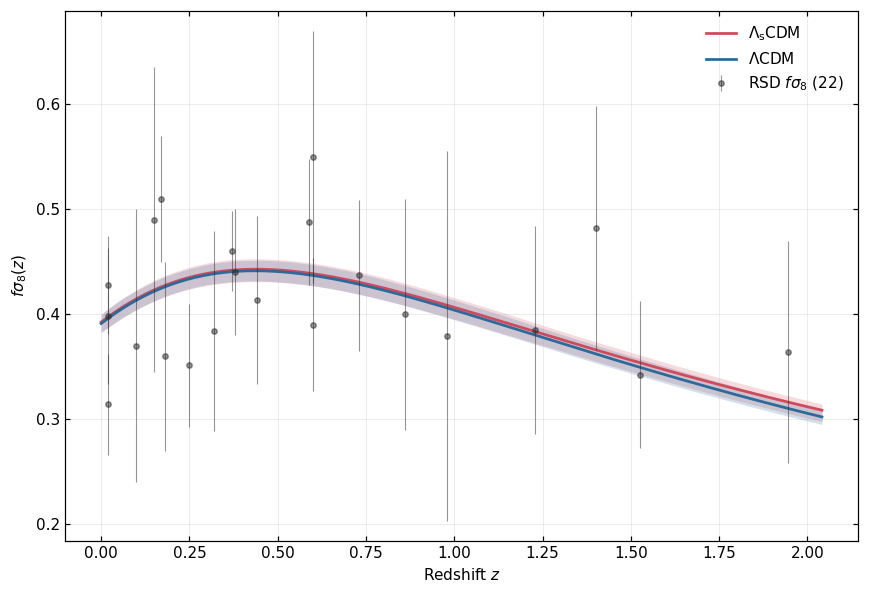

In [36]:
fig = fit_growth.plots.compare_growth(other_fits=fit_lcdm_growth)
savefig(fig, "compare_growth");

### Verdict on $S_8$

**The two models are indistinguishable.** $S_8$ comes out at
$0.7623 \pm 0.0174$ and $0.7621 \pm 0.0179$ — a 0.03% difference,
inside the uncertainty by a factor of 75 — and the $f\sigma_8$
$\chi^2$ differs by 0.09 across 22 points. Adding 23 growth points
moves $z_\dagger$ from 2.91 to 2.89 and $H_0$ from 68.55 to 68.60,
and $\Delta\chi^2$ goes from $-5.41$ to $-5.51$: the growth data
neither supports $\Lambda_{\rm s}$CDM nor rules it out.

**And the canonical test is not available here.** Relieving the $S_8$
tension means lowering the *CMB-predicted* $S_8$ toward the lensing
value. That comparison needs the CMB amplitude, which needs the full
TT/TE/EE spectra, which — as established in section 2 —
$\Lambda_{\rm s}$CDM cannot be given to a Boltzmann code for. Within
this framework the tension cannot even be posed for this model, let
alone resolved.

What *can* be said without the CMB is the fixed-parameter prediction
above: the sign switch changes growth by 0.4%, in the direction that
makes $S_8$ slightly worse. Whatever the full analysis would find, it
is not going to find a 10% effect in a model whose growth differs by
0.4%.

So the joint claim does not survive this data combination on either
half. $H_0$ because DESI DR2 pushes $z_\dagger$ out of the range where
the mechanism worked; $S_8$ because the mechanism was never large
enough to matter.

## 15. Is any of this a DESI result?

Section 8 found the constraint on $z_\dagger$ by profiling, and what
it found was a **cliff**: $\chi^2$ falls by 28 between
$z_\dagger = 2.30$ and $z_\dagger = 2.40$, straddling DESI's
Lyman-$\alpha$ bin at $z = 2.33$. That is not subtle, and it raises
an obvious question the notebook could not answer when it was
written: is this a property of the universe, or of one measurement?

The library can now answer it. As of v0.29.0 it carries **eBOSS
DR16's Lyman-$\alpha$ BAO at $z_{\rm eff} = 2.334$** -- a different
survey, a different pipeline, essentially the same redshift -- along
with the rest of eBOSS DR16. So the entire fit can be redone with
DESI removed and its predecessor put in its place, keeping every
other ingredient identical.

The two BAO sets are *not* independent of each other (DESI
re-observes much of the same sky, which is why the library refuses
to combine them), so this is a replacement, not an addition.

In [37]:
# Identical apart from the BAO. DESI's five tracers come out; eBOSS
# DR16's LRG+QSO (`sdss_bao`), ELG and Lyman-alpha go in.
EBOSS_DATASETS = [
    "cc", "sdss_bao", "eboss_elg", "eboss_lya",
    "bao_lowz", "des_sn5yr", "planck", "omega_b",
]

for name in ("eboss_elg", "eboss_lya"):
    print(f"{name:>10}  {dataset_reference(name)}\n")

 eboss_elg  eBOSS DR16 ELG BAO -- de Mattia et al. (2020), MNRAS 501, 5616, arXiv:2007.09008. D_V/r_d = 18.33 (+0.57/-0.62) at z_eff = 0.845, from a 1.4-sigma BAO detection.
 eboss_lya  eBOSS DR16 Lyman-alpha BAO -- du Mas des Bourboux et al. (2020), ApJ 901, 153, arXiv:2007.08995. D_M/r_d = 37.5 +- 1.1, D_H/r_d = 8.99 +- 0.19 at z_eff = 2.334, from the forest auto-correlation combined with its cross-correlation with quasars.


### The headline, both ways

Every fit below uses `restarts=`. That is not caution for its own
sake: $\Lambda_{\rm s}$CDM's surface has a second basin on the wrong
side of the cliff, and a single-start fit landed in it and returned
a $\chi^2$ *higher* than nested $\Lambda$CDM's -- which is
impossible, since $\Lambda_{\rm s}$CDM contains $\Lambda$CDM at
$z_\dagger \to \infty$. That impossibility is the only reason the
failure was noticed, and it is worth keeping the check visible.

In [38]:
def headline(datasets, kwargs=None, restarts=12):
    """Best-fit LCDM and LsCDM for one dataset combination."""

    base = {k: v for k, v in INITIAL.items() if k != "z_dagger"}

    lcdm = Fitter(
        model=LCDM, datasets=datasets, dataset_kwargs=kwargs,
        free_params=["H0", "Omega_m", "Omega_b"],
        initial=base, compute_rd=True,
    )
    lcdm.best_fit(restarts=restarts, seed=SEEDS["lcdm"])

    lscdm = Fitter(
        model=LsCDM, datasets=datasets, dataset_kwargs=kwargs,
        free_params=FREE_LSCDM, initial=INITIAL,
        bounds={"z_dagger": (0.5, 100.0)}, compute_rd=True,
    )
    lscdm.best_fit(restarts=restarts, seed=SEEDS["lscdm"])

    return lcdm, lscdm


runs = {
    "DESI DR2": headline(DATASETS, DATASET_KWARGS),
    "eBOSS DR16": headline(EBOSS_DATASETS),
}

print(f"{'BAO':<12}{'N':>6}{'LCDM':>10}{'LsCDM':>10}"
      f"{'delta chi2':>12}{'z_dagger':>10}{'H0':>8}")

for label, (lcdm, lscdm) in runs.items():
    delta = lcdm.best_fit_chi2 - lscdm.best_fit_chi2
    assert delta >= -1e-6, "nested model fits worse -- optimizer failed"
    print(f"{label:<12}{lcdm.n_data:>6}{lcdm.best_fit_chi2:>10.2f}"
          f"{lscdm.best_fit_chi2:>10.2f}{delta:>+12.2f}"
          f"{lscdm.best_fit_params['z_dagger']:>10.2f}"
          f"{lscdm.best_fit_params['H0']:>8.2f}")

/home/talos/miniconda3/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/home/talos/CosmoFit/src/CosmoFit/stats/fitter.py:1876: UserWarning: best_fit() did not move from its starting point: L-BFGS-B's default finite-difference step (~1.5e-8) is too small for this likelihood to respond to, which happens when a Boltzmann code's own numerical noise exceeds the chi2 change such a step produces. Retrying with Nelder-Mead, which needs no gradient. This is slower; pass `method=` or `eps=` to control it.
  result = self._single_best_fit(x0, bounds, options, eps, method)


/home/talos/CosmoFit/src/CosmoFit/stats/fitter.py:1884: UserWarning: best_fit() did not move from its starting point: L-BFGS-B's default finite-difference step (~1.5e-8) is too small for this likelihood to respond to, which happens when a Boltzmann code's own numerical noise exceeds the chi2 change such a step produces. Retrying with Nelder-Mead, which needs no gradient. This is slower; pass `method=` or `eps=` to control it.
  candidate = self._single_best_fit(


BAO              N      LCDM     LsCDM  delta chi2  z_dagger      H0
DESI DR2      1871   1665.74   1660.35       +5.40      2.50   68.68
eBOSS DR16    1869   1658.71   1658.41       +0.30      4.02   67.59


**The preference does not survive.** $\Delta\chi^2 = 5.4$ with DESI
becomes $0.3$ with eBOSS -- one extra parameter buying nothing at
all. And $H_0$, which section 6 reported as $68.55 \pm 0.30$ under
$\Lambda_{\rm s}$CDM, comes back near $67.6$.

Before reading anything into that, note what it is *not*: eBOSS's
BAO is less precise than DESI's, so a weaker preference is partly
expected. The profile below separates the two possibilities.

In [39]:
def profile(datasets, kwargs=None):
    """chi2 at fixed z_dagger, with the other three re-optimized."""

    out = []

    for z in Z_GRID_CHECK:
        f = Fitter(
            model=LsCDM, datasets=datasets, dataset_kwargs=kwargs,
            free_params=["H0", "Omega_m", "Omega_b"],
            initial={**INITIAL, "z_dagger": float(z)},
            bounds={"z_dagger": (0.5, 100.0)}, compute_rd=True,
        )
        f.best_fit()
        out.append(f.best_fit_chi2)

    return np.array(out)


Z_GRID_CHECK = np.concatenate([
    np.arange(1.2, 4.01, 0.1), [4.5, 5.0, 6.0, 8.0, 12.0, 20.0],
])

profiles = {
    "DESI DR2": profile(DATASETS, DATASET_KWARGS),
    "eBOSS DR16": profile(EBOSS_DATASETS),
}

# The question is not "where is this curve steepest" -- both fall
# steeply below z_dagger = 1.5, where the sign switch is simply too
# recent to fit anything. It is how much chi2 moves across the
# Lyman-alpha redshift specifically.
lo = int(np.argmin(np.abs(Z_GRID_CHECK - 2.30)))
hi = int(np.argmin(np.abs(Z_GRID_CHECK - 2.40)))

print(f"{'BAO':<12}{'chi2(2.30)':>12}{'chi2(2.40)':>12}{'step':>9}")

for label, curve in profiles.items():
    print(f"{label:<12}{curve[lo]:>12.2f}{curve[hi]:>12.2f}"
          f"{curve[lo] - curve[hi]:>+9.2f}")

BAO           chi2(2.30)  chi2(2.40)     step
DESI DR2         1688.57     1660.53   +28.04
eBOSS DR16       1658.86     1660.46    -1.59


saved zdagger_profile_desi_vs_eboss.svg (0.05 MB)


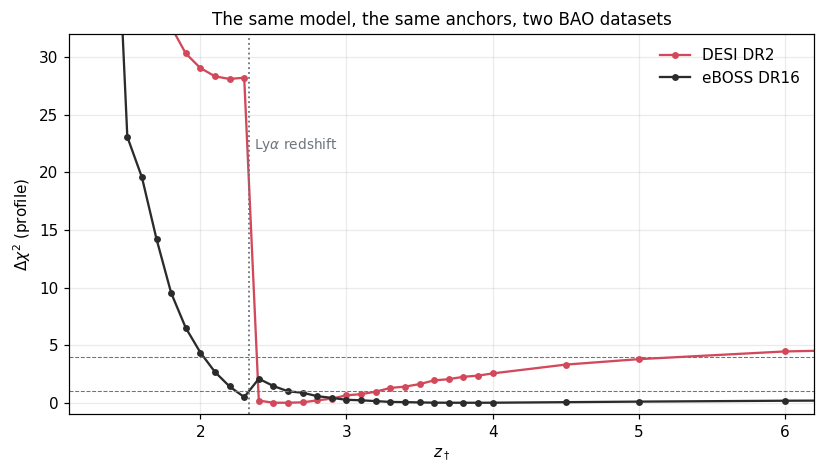

In [40]:
fig, ax = plt.subplots(figsize=(7.6, 4.4))

for (label, curve), color in zip(profiles.items(), ("#d1495b", "#2b2b2b")):
    ax.plot(
        Z_GRID_CHECK, curve - curve.min(), "o-", ms=3.5, lw=1.5,
        color=color, label=label,
    )

ax.axvline(2.33, color="#6c757d", ls=":", lw=1.2)
ax.text(
    2.37, 22.0, r"Ly$\alpha$ redshift", fontsize=9, color="#6c757d",
)

for level in (1.0, 4.0):
    ax.axhline(level, color="#6c757d", lw=0.7, ls="--")

ax.set_xlabel(r"$z_\dagger$")
ax.set_ylabel(r"$\Delta\chi^2$ (profile)")
ax.set_xlim(1.1, 6.2)
ax.set_ylim(-1.0, 32.0)
ax.set_title(
    "The same model, the same anchors, two BAO datasets", fontsize=11,
)
ax.legend(frameon=False)
ax.grid(alpha=0.25)

fig.tight_layout()
savefig(fig, "zdagger_profile_desi_vs_eboss");

The shapes are not the same shape.

DESI's profile has the cliff -- $\chi^2$ drops by 28.04 between two
adjacent grid points at the Lyman-$\alpha$ redshift. eBOSS's, over
the same grid with a Lyman-$\alpha$ measurement at essentially the
same redshift, crosses it with a **1.6-unit ripple** instead, in the
opposite direction, and is otherwise a smooth bowl falling from
$z_\dagger = 1.2$ and flattening above $z_\dagger \approx 3.5$. It
is not perfectly monotonic -- the ripple is visible in the figure and
reproduces under a multi-start scan, so it is a real if minor
echo of the same effect -- but it is a ripple and not a cliff.

Both curves were checked against a multi-start scan and reproduce
exactly, so neither the cliff nor the smoothness is optimizer noise.

The cliff is a **precision** effect, and it is worth being precise
about which precision. DESI measures $D_H/r_d$ at $z = 2.33$ to
1.2%; eBOSS measures it at $z = 2.334$ to 2.1%. A $\chi^2$ feature
scales as $1/\sigma^2$, so the same physical discrepancy would show
up about three times weaker in eBOSS -- and $28/3 \approx 9$, not
the $1.6$ actually seen. Precision explains part of it, and not all.

### Where the 5.4 actually comes from

The natural guess is the Lyman-$\alpha$ point, since that is where
the cliff is. The $\chi^2$ breakdown says otherwise.

In [41]:
for label, (lcdm, lscdm) in runs.items():
    print(f"\n{label}:  LCDM {lcdm.best_fit_chi2:.2f} -> "
          f"LsCDM {lscdm.best_fit_chi2:.2f}")
    print(f"   {'dataset':<18}{'LCDM':>9}{'LsCDM':>9}{'improvement':>13}")

    for a, b in zip(lcdm.likelihoods, lscdm.likelihoods):
        print(f"   {a.name:<18}{a.chi2():>9.2f}{b.chi2():>9.2f}"
              f"{a.chi2() - b.chi2():>+13.2f}")

DESI DR2:  LCDM 1665.74 -> LsCDM 1660.35
   dataset                LCDM    LsCDM  improvement
   CC                    13.14    13.06        +0.08
   DESI                  13.03    10.91        +2.12
   BAO low-z              1.56     1.75        -0.19


   DES-SN5YR           1634.85  1634.45        +0.40
   Planck                 2.83     0.10        +2.72
   BBN                    0.33     0.07        +0.27
eBOSS DR16:  LCDM 1658.71 -> LsCDM 1658.41
   dataset                LCDM    LsCDM  improvement
   CC                    13.33    13.29        +0.04
   SDSS-BAO               6.46     6.14        +0.32
   eBOSS-DR16-ELG         0.34     0.29        +0.05
   eBOSS-DR16-Lya         4.81     4.96        -0.15
   BAO low-z              0.91     0.97        -0.06
   DES-SN5YR           1632.62  1632.64        -0.02
   Planck                 0.10     0.03        +0.06
   BBN                    0.13     0.08        +0.05


With DESI, the single largest gain is **Planck**: $\chi^2$ falls
from 2.83 to 0.10 on three compressed data points. DESI's own BAO
contributes 2.12, and everything else is noise.

That is the whole mechanism, and it is not about Lyman-$\alpha$ at
all. Under $\Lambda$CDM, DESI's BAO and Planck's distance priors
cannot both be satisfied: something has to give, and it shows up as
$\chi^2_{\rm Planck} = 2.83$ for three points. $\Lambda_{\rm s}$CDM
relaxes the late-time expansion history enough to satisfy both at
once, which is precisely the tension it was proposed to address.

With eBOSS there is nothing to relax. $\chi^2_{\rm Planck}$ is
already $0.10$ under plain $\Lambda$CDM, because eBOSS's BAO pulls
$H_0$ to $67.4$ -- where Planck wants it. A model that resolves a
tension has no work to do when there is no tension.

So the cliff and the preference are two separate things with two
separate causes: the cliff is DESI's Lyman-$\alpha$ *precision*, and
the preference is a $\Lambda$CDM disagreement between DESI's BAO and
the CMB.

### Which Lyman-$\alpha$ is the odd one out?

Having assumed DESI's measurement was driving an anomaly, it is
worth checking whether it is even the anomalous one. Both are
compared here against a $\Lambda$CDM fit containing **no
Lyman-$\alpha$ data at all**, so neither is judged against a fit it
helped make.

In [42]:
neutral = Fitter(
    model=LCDM,
    datasets=["cc", "bao_lowz", "des_sn5yr", "planck", "omega_b"],
    free_params=["H0", "Omega_m", "Omega_b"],
    initial={k: v for k, v in INITIAL.items() if k != "z_dagger"},
    compute_rd=True,
)
neutral.best_fit(restarts=8, seed=SEEDS["lcdm"])

c = neutral.cosmology
predicted = {
    "DM_over_rs": c.distance.DM(2.33) / c.rd,
    "DH_over_rs": c.distance.DH(2.33) / c.rd,
}

print(f"LCDM without any Lyman-alpha:  H0 = "
      f"{neutral.best_fit_params['H0']:.2f}, "
      f"Omega_m = {neutral.best_fit_params['Omega_m']:.4f}")
print(f"  predicts  DM/rd = {predicted['DM_over_rs']:.2f}   "
      f"DH/rd = {predicted['DH_over_rs']:.3f}\n")

measured = {
    "DESI DR2 (z=2.330)":  ((38.989, 0.532), (8.632, 0.101)),
    "eBOSS DR16 (z=2.334)": ((37.525, 1.138), (8.998, 0.191)),
}

print(f"{'survey':<22}{'DM/rd':>18}{'pull':>8}{'DH/rd':>18}{'pull':>8}")
for label, ((dm, sdm), (dh, sdh)) in measured.items():
    print(f"{label:<22}{dm:>10.2f} +-{sdm:5.2f}"
          f"{(dm - predicted['DM_over_rs']) / sdm:>+8.2f}"
          f"{dh:>10.3f} +-{sdh:5.3f}"
          f"{(dh - predicted['DH_over_rs']) / sdh:>+8.2f}")

LCDM without any Lyman-alpha:  H0 = 67.00, Omega_m = 0.3200
  predicts  DM/rd = 39.26   DH/rd = 8.611
survey                             DM/rd    pull             DH/rd    pull
DESI DR2 (z=2.330)         38.99 +- 0.53   -0.52     8.632 +-0.101   +0.20
eBOSS DR16 (z=2.334)       37.52 +- 1.14   -1.53     8.998 +-0.191   +2.02


The expectation was backwards. **DESI's Lyman-$\alpha$ agrees with
$\Lambda$CDM** to half a sigma; **eBOSS's is the one sitting
$2.0\sigma$ away** in $D_H/r_d$. The two disagree with each other at
$1.2\sigma$ and $1.7\sigma$ in the two ratios -- not a crisis, but
not nothing either, and enough that which one is used matters.

That reframes the cliff completely. It is not DESI's Lyman-$\alpha$
pulling towards new physics. It is DESI's Lyman-$\alpha$ being
precise, and sitting where $\Lambda$CDM says it should, and
therefore sharply *forbidding* the sign switch from happening below
$z = 2.33$. The cliff is an exclusion, not a detection -- which is
exactly what section 8's one-sided bound $z_\dagger > 2.36$ said,
and it now has an independent reason to be believed as a bound and
not as evidence for the model.

### Verdict

The $\Lambda_{\rm s}$CDM result in this notebook is a **DESI**
result. Stated plainly:

* The $\Delta\chi^2 = 5.4$ preference over $\Lambda$CDM falls to
  $0.3$ when DESI's BAO is replaced by eBOSS DR16's. One extra
  parameter, nothing bought.
* The mechanism is a $\Lambda$CDM disagreement between DESI's BAO
  and Planck's distance priors, worth 2.7 of the 5.4 on three data
  points. eBOSS has no such disagreement to resolve.
* The sharp lower bound on $z_\dagger$ is set by the *precision* of
  DESI's Lyman-$\alpha$ measurement, not by any anomaly in it -- of
  the two Lyman-$\alpha$ measurements, DESI's is the one that agrees
  with $\Lambda$CDM.

None of this says $\Lambda_{\rm s}$CDM is wrong. It says the
evidence for it in this dataset combination rests on one survey, and
that the honest way to report the $H_0 = 68.55 \pm 0.30$ of section
6 is with that dependence attached.

## Summary

Fitting $\Lambda_{\rm s}$CDM to CC + DESI DR2 BAO + low-$z$ BAO +
DES-SN5YR + Planck distance priors + BBN, with $r_d$ computed rather
than fitted:

| | $\Lambda$CDM | $\Lambda_{\rm s}$CDM |
|---|---|---|
| $\chi^2$ (1871 points) | 1665.7 | **1660.3** |
| $\Delta$AIC | 0 | $-3.4$ |
| $\Delta$BIC | 0 | $+2.1$ |
| $H_0$ | $68.25 \pm 0.28$ | $68.55 \pm 0.30$ |
| tension with SH0ES | $4.4\sigma$ | $4.1\sigma$ |
| $z_\dagger$ | — | $> 2.36$ (95%) |
| $S_8$ (with growth data) | $0.762 \pm 0.018$ | $0.762 \pm 0.017$ |

**Four things came out of this.**

1. **The sign switch is pushed above the BAO data.** The profile
   likelihood has a cliff of $\Delta\chi^2 \approx 28$ between
   $z_\dagger = 2.20$ and $2.35$, straddling DESI DR2's
   Lyman-$\alpha$ bin at $z = 2.33$. Below that redshift the model is
   strongly excluded.

2. **A mild preference, not a detection.** $\Delta\chi^2 = -5.4$ for
   one extra parameter: AIC prefers $\Lambda_{\rm s}$CDM, BIC prefers
   $\Lambda$CDM, and no likelihood-ratio $p$-value is legitimate
   because $\Lambda$CDM sits at $z_\dagger \to \infty$ rather than at
   an interior point.

3. **The $H_0$ tension survives.** $\Lambda_{\rm s}$CDM's mechanism
   works — the profile shows $H_0 = 69.9$ at $z_\dagger = 1.0$ — but
   only where the data will not let $z_\dagger$ go. Forced above the
   BAO range, the lift is $0.3$ km s$^{-1}$ Mpc$^{-1}$ and the tension
   is essentially where $\Lambda$CDM left it.

4. **Quote the lower limit, not the median.** $z_\dagger$'s posterior
   has a $\Lambda$CDM plateau above it, so its median and upper error
   bar move with the prior. Only $z_\dagger > 2.36$ is a statement
   about the data.

5. **$S_8$ is untouched.** With growth data added (section 14) the two
   models give the same $S_8$ to 0.03% — and at fixed parameters the
   sign switch changes $f\sigma_8$ by 0.4%, in the direction that
   makes the tension slightly *worse*. The joint $H_0$–$S_8$ claim
   fails on both halves here: $H_0$ because DESI DR2 moves
   $z_\dagger$ out of range, $S_8$ because the effect was never big
   enough.

**Caveats worth naming.** The CMB enters as three compressed numbers,
and most of the $\Delta\chi^2$ is there; $\Lambda_{\rm s}$CDM has no
$w(z)$, so the full Planck spectra cannot be computed for it, and this
particular comparison cannot be tightened that way within CosmoFit.
The $S_8$ side is tested in section 14, with the important
qualification that the *canonical* $S_8$ tension cannot be posed at
all in this framework — the compressed CMB carries no amplitude
information, and the full spectra are unavailable for this model.

**Reproducing this.** `MASTER_SEED = 42` regenerates every chain
identically. Chains are cached in `lscdm_mcmc_chains/`; delete that
directory to re-sample from scratch. Figures are written to
`lscdm_mcmc_figures/` as SVG.

**References.** Akarsu, Kumar, Özülker & Vázquez (2021), Phys. Rev. D
104, 123512, [arXiv:2108.09239](https://arxiv.org/abs/2108.09239);
Akarsu, Kumar, Özülker, Vázquez & Yadav (2023), Phys. Rev. D 108,
023513, [arXiv:2211.05742](https://arxiv.org/abs/2211.05742). Data
references are printed in section 2, and collected in
[REFERENCES.md](../REFERENCES.md).

---

### Addendum: this is a DESI result (section 15)

Added after the fact, once the library carried an independent BAO
measurement at the Lyman-$\alpha$ redshift. Replacing DESI DR2 with
eBOSS DR16 and changing nothing else:

* the $\Delta\chi^2 = 5.40$ preference over $\Lambda$CDM becomes
  **0.30** -- one extra parameter buying nothing;
* the cliff at $z_\dagger \approx 2.35$, a 28.04-unit step with
  DESI, becomes a 1.6-unit ripple;
* the improvement with DESI is 2.72 in **Planck** and 2.12 in DESI's
  own BAO, so the mechanism is a $\Lambda$CDM disagreement between
  those two, not the Lyman-$\alpha$ point the cliff sits on. With
  eBOSS, $\chi^2_{\rm Planck}$ is already 0.10 under
  $\Lambda$CDM -- there is no tension to relieve.

And the assumption that motivated the check was wrong in a useful
way: against a $\Lambda$CDM fit containing no Lyman-$\alpha$ data,
**DESI's measurement is the one that agrees** ($-0.52\sigma$,
$+0.20\sigma$) and eBOSS's is $2.0\sigma$ off in $D_H/r_d$. The
cliff is an exclusion set by DESI's precision, not a detection.

Everything above stands as a description of that dataset
combination. Section 15 is the caveat that belongs with it.
